In [1]:

# 한글 폰트 설정 (코랩용)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 나눔고딕 설치
os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')

# 폰트 캐시 초기화 + 등록
fm._load_fontmanager(try_read_cache=False)

# 나눔고딕으로 설정
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지



In [2]:
# Openml 설치

!pip install openml



---



# **2. 데이터 프로파일링 및 기초탐색 (Data Profiling)**



---



## **2.1_ 데이터 불러오기 (Data Import)**

In [3]:
"""
2.1 데이터 불러오기 - ① openml 라이브러리 사용
"""
import openml
import pandas as pd

# OpenML에서 데이터셋 ID 1464로 가져오기
dataset = openml.datasets.get_dataset(1464)
df1, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

# 타겟 변수(Class)가 별도로 분리되어 있으므로 다시 합치기
df1['Class'] = y

# 결과 확인
print("① openml 라이브러리 사용")
print(f"Shape: {df1.shape}")
print(f"컬럼명: {list(df1.columns)}")
print()
print(df1.head())

① openml 라이브러리 사용
Shape: (748, 5)
컬럼명: ['V1', 'V2', 'V3', 'V4', 'Class']

   V1  V2       V3  V4 Class
0   2  50  12500.0  98     2
1   0  13   3250.0  28     2
2   1  16   4000.0  35     2
3   2  20   5000.0  45     2
4   1  24   6000.0  77     1


In [4]:
"""
2.1 데이터 불러오기 - ② fetch_openml 사용 (sklearn)
"""
from sklearn.datasets import fetch_openml
import pandas as pd

# scikit-learn 내장 함수로 가져오기
data = fetch_openml(data_id=1464, as_frame=True, parser='auto')
df2 = data.frame.copy()

# 결과 확인
print("② fetch_openml 사용")
print(f"Shape: {df2.shape}")
print(f"컬럼명: {list(df2.columns)}")
print()
print(df2.head())


② fetch_openml 사용
Shape: (748, 5)
컬럼명: ['V1', 'V2', 'V3', 'V4', 'Class']

   V1  V2     V3  V4 Class
0   2  50  12500  98     2
1   0  13   3250  28     2
2   1  16   4000  35     2
3   2  20   5000  45     2
4   1  24   6000  77     1


In [5]:
"""
2.1 데이터 불러오기 - ③ StringIO 사용
"""
from io import StringIO
import requests
import pandas as pd

# URL에서 CSV 텍스트를 받아온 뒤, 파일 저장 없이 메모리에서 바로 읽기
url = "https://www.openml.org/data/get_csv/1586225/phpMYEkMl"
response = requests.get(url)
df3 = pd.read_csv(StringIO(response.text))

# 결과 확인
print("③ StringIO 사용")
print(f"Shape: {df3.shape}")
print(f"컬럼명: {list(df3.columns)}")
print()
print(df3.head())


③ StringIO 사용
Shape: (748, 5)
컬럼명: ['V1', 'V2', 'V3', 'V4', 'Class']

   V1  V2     V3  V4  Class
0   2  50  12500  98      2
1   0  13   3250  28      2
2   1  16   4000  35      2
3   2  20   5000  45      2
4   1  24   6000  77      1


In [6]:
"""
2.1 데이터 불러오기 - ④ requests 사용
"""
import requests
import pandas as pd

# URL에서 CSV 다운로드 → 파일로 저장 → 읽기
url = "https://www.openml.org/data/get_csv/1586225/phpMYEkMl"
response = requests.get(url)

with open("blood_transfusion.csv", "w") as f:
    f.write(response.text)

df4 = pd.read_csv("blood_transfusion.csv")

# 결과 확인
print("④ requests 사용")
print(f"Shape: {df4.shape}")
print(f"컬럼명: {list(df4.columns)}")
print()
print(df4.head())


④ requests 사용
Shape: (748, 5)
컬럼명: ['V1', 'V2', 'V3', 'V4', 'Class']

   V1  V2     V3  V4  Class
0   2  50  12500  98      2
1   0  13   3250  28      2
2   1  16   4000  35      2
3   2  20   5000  45      2
4   1  24   6000  77      1


In [7]:
"""
2.1 데이터 불러오기 - ⑤ 결과 동일성 확인 + 분석용 데이터프레임 통일
※ 위 4개 셀을 모두 실행한 후에 이 셀을 실행하세요
"""
import pandas as pd

# 4가지 방법 shape 비교
print("=" * 50)
print("4가지 방법 결과 비교")
print("=" * 50)
print(f"① openml:      {df1.shape}")
print(f"② fetch_openml: {df2.shape}")
print(f"③ StringIO:     {df3.shape}")
print(f"④ requests:     {df4.shape}")
print()
print("→ 4가지 방법 모두 동일한 결과 확인 완료")

# 이후 분석에 사용할 통합 데이터프레임 (②번 기준)
df = df2.copy()
df.columns = ['Recency', 'Frequency', 'Monetary', 'Time', 'Class']

# 데이터 타입 통일
df['Recency'] = df['Recency'].astype(float)
df['Frequency'] = df['Frequency'].astype(float)
df['Monetary'] = df['Monetary'].astype(float)
df['Time'] = df['Time'].astype(float)
df['Class'] = df['Class'].astype(int)

# Class 값 변환 (1→0 미헌혈, 2→1 헌혈)
df['Class'] = df['Class'].replace({1: 0, 2: 1})

print()
print("=" * 50)
print("이후 분석용 통합 데이터프레임 (df)")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"Dtypes:\n{df.dtypes}")
print(f"\nClass 값 확인: {df['Class'].unique()}")
print(f"Class 분포:\n{df['Class'].value_counts()}")
print()
print(df.head())


4가지 방법 결과 비교
① openml:      (748, 5)
② fetch_openml: (748, 5)
③ StringIO:     (748, 5)
④ requests:     (748, 5)

→ 4가지 방법 모두 동일한 결과 확인 완료

이후 분석용 통합 데이터프레임 (df)
Shape: (748, 5)
Dtypes:
Recency      float64
Frequency    float64
Monetary     float64
Time         float64
Class          int64
dtype: object

Class 값 확인: [1 0]
Class 분포:
Class
0    570
1    178
Name: count, dtype: int64

   Recency  Frequency  Monetary  Time  Class
0      2.0       50.0   12500.0  98.0      1
1      0.0       13.0    3250.0  28.0      1
2      1.0       16.0    4000.0  35.0      1
3      2.0       20.0    5000.0  45.0      1
4      1.0       24.0    6000.0  77.0      0


## **2.2_데이터 명세확인**

In [8]:
"""
2.2 데이터 명세 확인
※ 2.1의 통합확인 셀(df 생성)을 먼저 실행한 후에 실행하세요
"""

# --- df.info() ---
print("=" * 50)
print("df.info()")
print("=" * 50)
df.info()

# --- df.shape ---
print()
print("=" * 50)
print("df.shape")
print("=" * 50)
print(f"df.shape: {df.shape}")

# --- 보고서 표 채우기용 정리 ---
print()
print("=" * 50)
print("보고서 표 채우기용")
print("=" * 50)

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
dup_count = df.duplicated().sum()

print(f"전체 레코드 수: {df.shape[0]}행")
print(f"컬럼 수:        {df.shape[1]}열")
print(f"수치형 변수:    {len(numeric_cols)}개")
print(f"  → {list(numeric_cols)}")
print(f"범주형 변수:    1개 (Class - 실질적으로 범주형)")
print(f"중복 행 수:     {dup_count}개")

# --- Dtype 확인 ---
print()
print("=" * 50)
print("각 컬럼별 Dtype")
print("=" * 50)
print(df.dtypes)

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    748 non-null    float64
 1   Frequency  748 non-null    float64
 2   Monetary   748 non-null    float64
 3   Time       748 non-null    float64
 4   Class      748 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 29.3 KB

df.shape
df.shape: (748, 5)

보고서 표 채우기용
전체 레코드 수: 748행
컬럼 수:        5열
수치형 변수:    5개
  → ['Recency', 'Frequency', 'Monetary', 'Time', 'Class']
범주형 변수:    1개 (Class - 실질적으로 범주형)
중복 행 수:     215개

각 컬럼별 Dtype
Recency      float64
Frequency    float64
Monetary     float64
Time         float64
Class          int64
dtype: object


## **2.3_결측치(Missing Value) 분석**

In [9]:
"""
2.3 결측치(Missing Value) 분석
"""

# --- 결측치 확인 ---
print("=" * 50)
print("df.isnull().sum()")
print("=" * 50)
print(df.isnull().sum())

# --- 보고서 표 채우기용 ---
print()
print("=" * 50)
print("보고서 표 채우기용")
print("=" * 50)

for col in df.columns:
    missing = df[col].isnull().sum()
    pct = round(missing / len(df) * 100, 2)
    print(f"{col:12s} | 결측치 수: {missing}개 | 결측 비율: {pct}%")

print()
total_missing = df.isnull().sum().sum()
print(f"총 결측치: {total_missing}개")

if total_missing == 0:
    print("→ 결측치가 없으므로 별도 처리 불필요")
else:
    print("→ 결측치 처리 필요")

df.isnull().sum()
Recency      0
Frequency    0
Monetary     0
Time         0
Class        0
dtype: int64

보고서 표 채우기용
Recency      | 결측치 수: 0개 | 결측 비율: 0.0%
Frequency    | 결측치 수: 0개 | 결측 비율: 0.0%
Monetary     | 결측치 수: 0개 | 결측 비율: 0.0%
Time         | 결측치 수: 0개 | 결측 비율: 0.0%
Class        | 결측치 수: 0개 | 결측 비율: 0.0%

총 결측치: 0개
→ 결측치가 없으므로 별도 처리 불필요


## **2.4_기초 통계량 분석**

In [10]:
"""
2.4 기초 통계량 분석
  - 대표값: 평균, 중앙값, 최빈값
  - 산포: 범위, Q1/Q2/Q3, 사분위범위, 90%백분위수, 분산, 표준편차
  - 분포의 왜곡: 왜도, 첨도
"""

# --- df.describe() ---
print("=" * 50)
print("df.describe()")
print("=" * 50)
print(df.describe())

# --- 변수별 상세 통계량 (3가지 카테고리) ---
print()
print("=" * 60)
print("보고서 표 채우기용 상세 통계량")
print("=" * 60)

for col in ['Recency', 'Frequency', 'Monetary', 'Time']:
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    range_val = df[col].max() - df[col].min()

    print(f"\n{'='*50}")
    print(f"  {col}")
    print(f"{'='*50}")

    # 대표값
    print(f"\n  [대표값]")
    print(f"    평균 (mean):      {df[col].mean():.2f}")
    print(f"    중앙값 (median):  {df[col].median():.2f}")
    print(f"    최빈값 (mode):    {df[col].mode().values[0]:.2f}")

    # 산포
    print(f"\n  [산포]")
    print(f"    범위 (range):     {range_val:.2f}")
    print(f"    Q1 (25%):         {q1:.2f}")
    print(f"    Q2 (50%):         {q2:.2f}")
    print(f"    Q3 (75%):         {q3:.2f}")
    print(f"    사분위범위 (IQR): {iqr:.2f}")
    print(f"    90% 백분위수:     {df[col].quantile(0.90):.2f}")
    print(f"    분산 (var):       {df[col].var():.2f}")
    print(f"    표준편차 (std):   {df[col].std():.2f}")

    # 분포의 왜곡
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis()

    print(f"\n  [분포의 왜곡]")
    print(f"    왜도 (skewness):  {skew_val:.3f}")
    print(f"    첨도 (kurtosis):  {kurt_val:.3f}")

# --- 평균 vs 중앙값 비교 ---
print()
print("=" * 60)
print("평균 vs 중앙값 비교 (이상치 존재 여부 판단)")
print("=" * 60)

for col in ['Recency', 'Frequency', 'Monetary', 'Time']:
    mean_val = df[col].mean()
    median_val = df[col].median()
    diff_pct = abs(mean_val - median_val) / mean_val * 100

    if mean_val > median_val:
        direction = "평균 > 중앙값 → 오른쪽 꼬리 (큰 값 쪽 이상치 가능)"
    else:
        direction = "평균 < 중앙값 → 왼쪽 꼬리"

    print(f"{col}: 평균={mean_val:.2f}, 중앙값={median_val:.2f}, 차이={diff_pct:.1f}% → {direction}")


df.describe()
          Recency   Frequency      Monetary        Time       Class
count  748.000000  748.000000    748.000000  748.000000  748.000000
mean     9.506684    5.514706   1378.676471   34.282086    0.237968
std      8.095396    5.839307   1459.826781   24.376714    0.426124
min      0.000000    1.000000    250.000000    2.000000    0.000000
25%      2.750000    2.000000    500.000000   16.000000    0.000000
50%      7.000000    4.000000   1000.000000   28.000000    0.000000
75%     14.000000    7.000000   1750.000000   50.000000    0.000000
max     74.000000   50.000000  12500.000000   98.000000    1.000000

보고서 표 채우기용 상세 통계량

  Recency

  [대표값]
    평균 (mean):      9.51
    중앙값 (median):  7.00
    최빈값 (mode):    2.00

  [산포]
    범위 (range):     74.00
    Q1 (25%):         2.75
    Q2 (50%):         7.00
    Q3 (75%):         14.00
    사분위범위 (IQR): 11.25
    90% 백분위수:     21.00
    분산 (var):       65.54
    표준편차 (std):   8.10

  [분포의 왜곡]
    왜도 (skewness):  1.880
    첨도 (kurt

## **2.5 데이터 정제(Cleaning) 결과**

중복 행 확인
중복 행 수: 215개

중복 행 샘플:
    Recency  Frequency  Monetary  Time  Class
14      2.0        6.0    1500.0  15.0      1
18      2.0        6.0    1500.0  15.0      1
19      2.0        3.0     750.0   4.0      1
20      2.0        3.0     750.0   4.0      1
22      2.0        6.0    1500.0  16.0      1
23      2.0        6.0    1500.0  16.0      1
26      4.0        6.0    1500.0  14.0      0
31      4.0       10.0    2500.0  28.0      1
32      4.0       10.0    2500.0  28.0      1
41      2.0        5.0    1250.0  16.0      0

→ 처리: 동일 값이 서로 다른 헌혈자의 기록일 수 있으므로 유지

이상치 탐지 (IQR 방법)

Recency:
  Q1=2.75, Q3=14.0, IQR=11.25
  하한=-14.125, 상한=30.875
  이상치: 7개 (0.9%)

Frequency:
  Q1=2.0, Q3=7.0, IQR=5.0
  하한=-5.5, 상한=14.5
  이상치: 45개 (6.0%)

Monetary:
  Q1=500.0, Q3=1750.0, IQR=1250.0
  하한=-1375.0, 상한=3625.0
  이상치: 45개 (6.0%)

Time:
  Q1=16.0, Q3=50.0, IQR=34.0
  하한=-35.0, 상한=101.0
  이상치: 0개 (0.0%)

→ 처리 방침: 이상치는 실제 헌혈 패턴을 반영하는 의미 있는 값이므로 제거하지 않고 유지


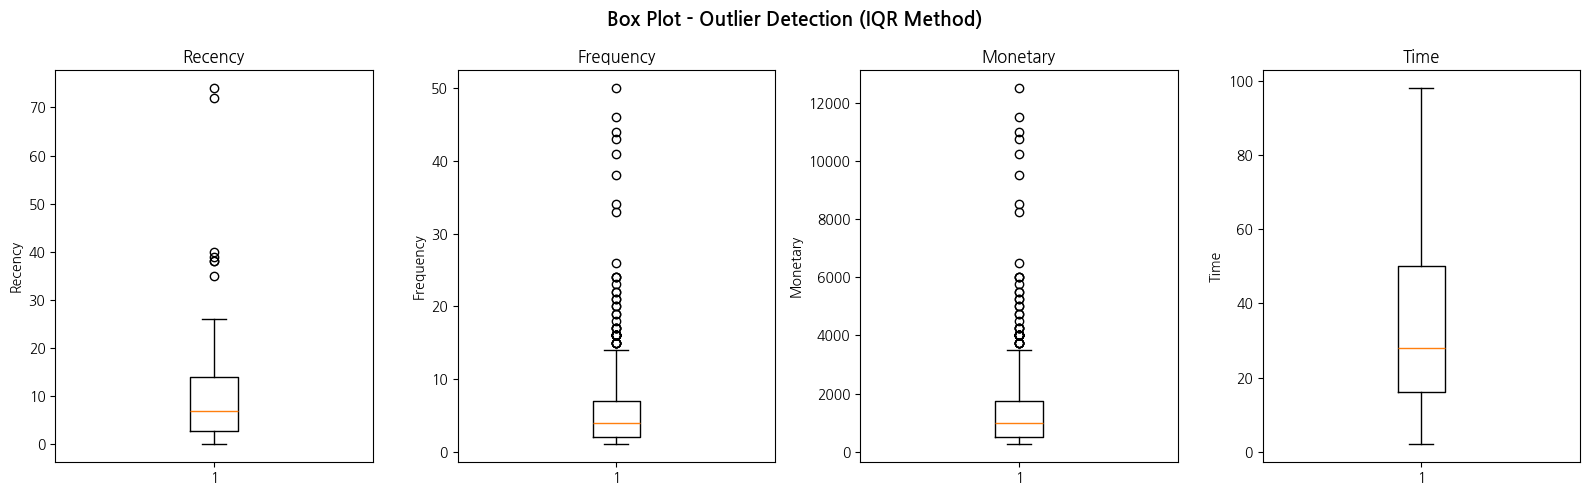

In [11]:
"""
2.5 데이터 정제(Cleaning) 결과
"""
import matplotlib.pyplot as plt

# --- 중복 행 확인 ---
print("=" * 50)
print("중복 행 확인")
print("=" * 50)

dup_count = df.duplicated().sum()
print(f"중복 행 수: {dup_count}개")

if dup_count > 0:
    print(f"\n중복 행 샘플:")
    print(df[df.duplicated(keep=False)].head(10))
    print(f"\n→ 처리: 동일 값이 서로 다른 헌혈자의 기록일 수 있으므로 유지")
else:
    print("→ 중복 행 없음")

# --- 이상치 탐지 (IQR 방법) ---
print()
print("=" * 50)
print("이상치 탐지 (IQR 방법)")
print("=" * 50)

for col in ['Recency', 'Frequency', 'Monetary', 'Time']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = len(outliers) / len(df) * 100

    print(f"\n{col}:")
    print(f"  Q1={q1}, Q3={q3}, IQR={iqr}")
    print(f"  하한={lower}, 상한={upper}")
    print(f"  이상치: {len(outliers)}개 ({pct:.1f}%)")

print()
print("→ 처리 방침: 이상치는 실제 헌혈 패턴을 반영하는 의미 있는 값이므로 제거하지 않고 유지")

# --- 이상치 시각화 (Box Plot) ---
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Box Plot - Outlier Detection (IQR Method)', fontsize=14, fontweight='bold')

for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'Time']):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()



---



# **3 .  변수별 개별 특성 분석 (Univariate Analysis)**



---



## **3.1_수치형 변수 분석**

3.1 수치형 변수별 왜도 / 첨도 / 분포 형태

--- Recency ---
  왜도 (Skewness): 1.880 → 강한 오른쪽(양의) 치우침
  첨도 (Kurtosis): 9.391 → 매우 뾰족 (이상치 많음)

--- Frequency ---
  왜도 (Skewness): 3.211 → 강한 오른쪽(양의) 치우침
  첨도 (Kurtosis): 15.876 → 매우 뾰족 (이상치 많음)

--- Monetary ---
  왜도 (Skewness): 3.211 → 강한 오른쪽(양의) 치우침
  첨도 (Kurtosis): 15.876 → 매우 뾰족 (이상치 많음)

--- Time ---
  왜도 (Skewness): 0.749 → 약한 오른쪽(양의) 치우침
  첨도 (Kurtosis): -0.246 → 정규분포에 가까움


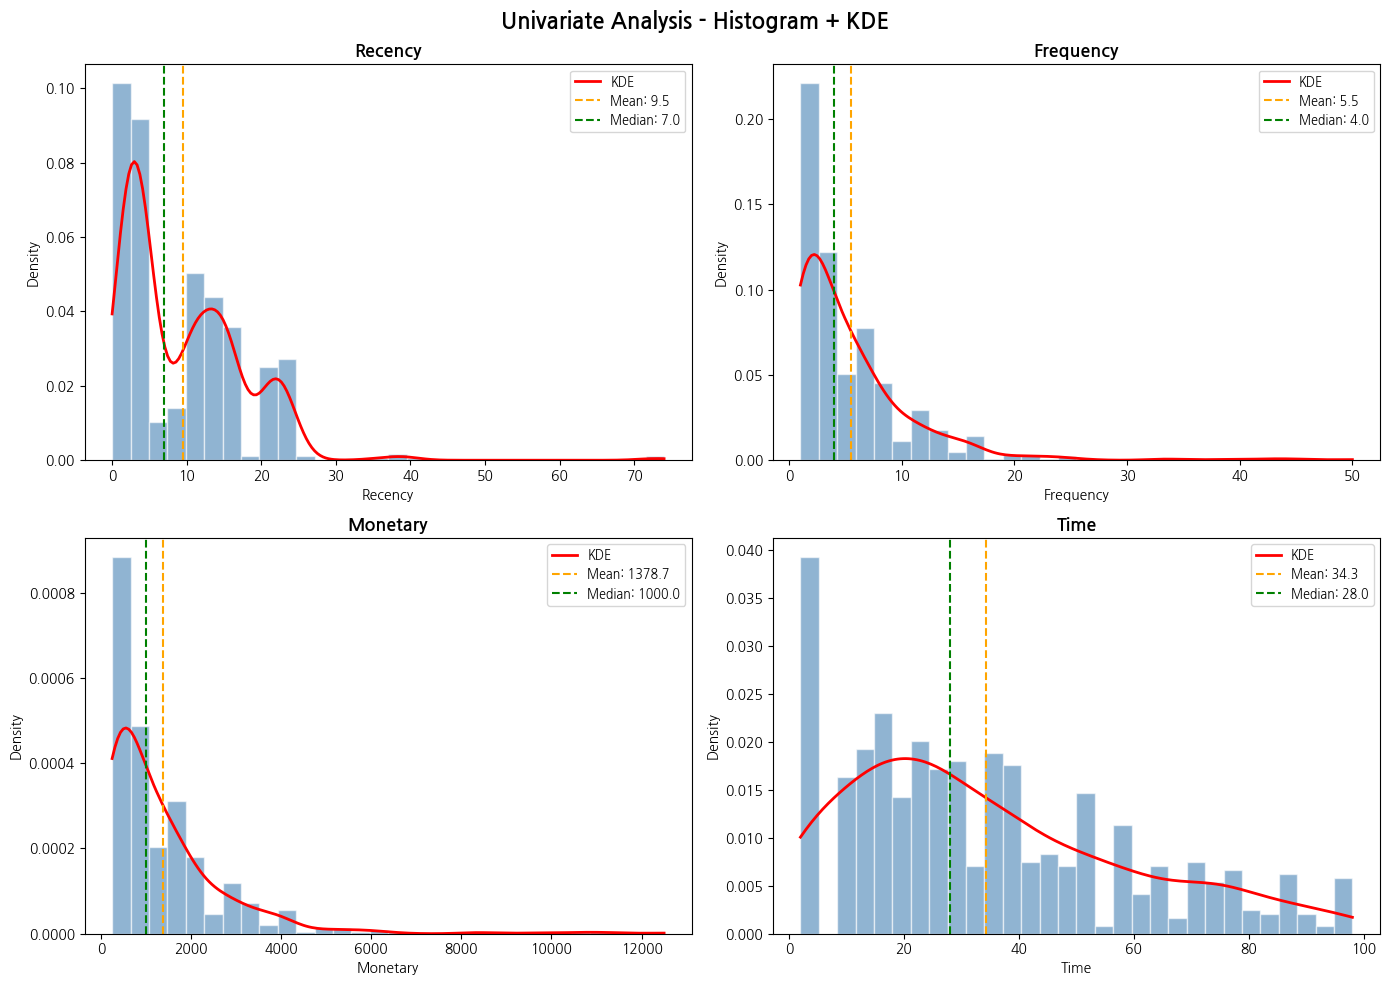

In [12]:
"""
3.1 수치형 변수 분석 (히스토그램 + KDE + 왜도/첨도)
"""
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis - Histogram + KDE', fontsize=16, fontweight='bold')

variables = ['Recency', 'Frequency', 'Monetary', 'Time']
axes_flat = axes.flatten()

print("=" * 60)
print("3.1 수치형 변수별 왜도 / 첨도 / 분포 형태")
print("=" * 60)

for i, col in enumerate(variables):
    ax = axes_flat[i]

    # 히스토그램 + KDE
    ax.hist(df[col], bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='white')

    # KDE 곡선
    x_range = np.linspace(df[col].min(), df[col].max(), 200)
    kde = stats.gaussian_kde(df[col])
    ax.plot(x_range, kde(x_range), color='red', linewidth=2, label='KDE')

    # 평균, 중앙값 표시
    ax.axvline(df[col].mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.1f}')

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

    # 왜도, 첨도 계산
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis()

    # 분포 형태 해석
    if skew_val > 1:
        skew_text = "강한 오른쪽(양의) 치우침"
    elif skew_val > 0.5:
        skew_text = "약한 오른쪽(양의) 치우침"
    elif skew_val < -1:
        skew_text = "강한 왼쪽(음의) 치우침"
    elif skew_val < -0.5:
        skew_text = "약한 왼쪽(음의) 치우침"
    else:
        skew_text = "대칭에 가까움"

    if kurt_val > 3:
        kurt_text = "매우 뾰족 (이상치 많음)"
    elif kurt_val > 1:
        kurt_text = "뾰족한 편"
    elif kurt_val < -1:
        kurt_text = "납작한 편"
    else:
        kurt_text = "정규분포에 가까움"

    print(f"\n--- {col} ---")
    print(f"  왜도 (Skewness): {skew_val:.3f} → {skew_text}")
    print(f"  첨도 (Kurtosis): {kurt_val:.3f} → {kurt_text}")

plt.tight_layout()
plt.show()

## **3.2_왜곡 변수 전처리**

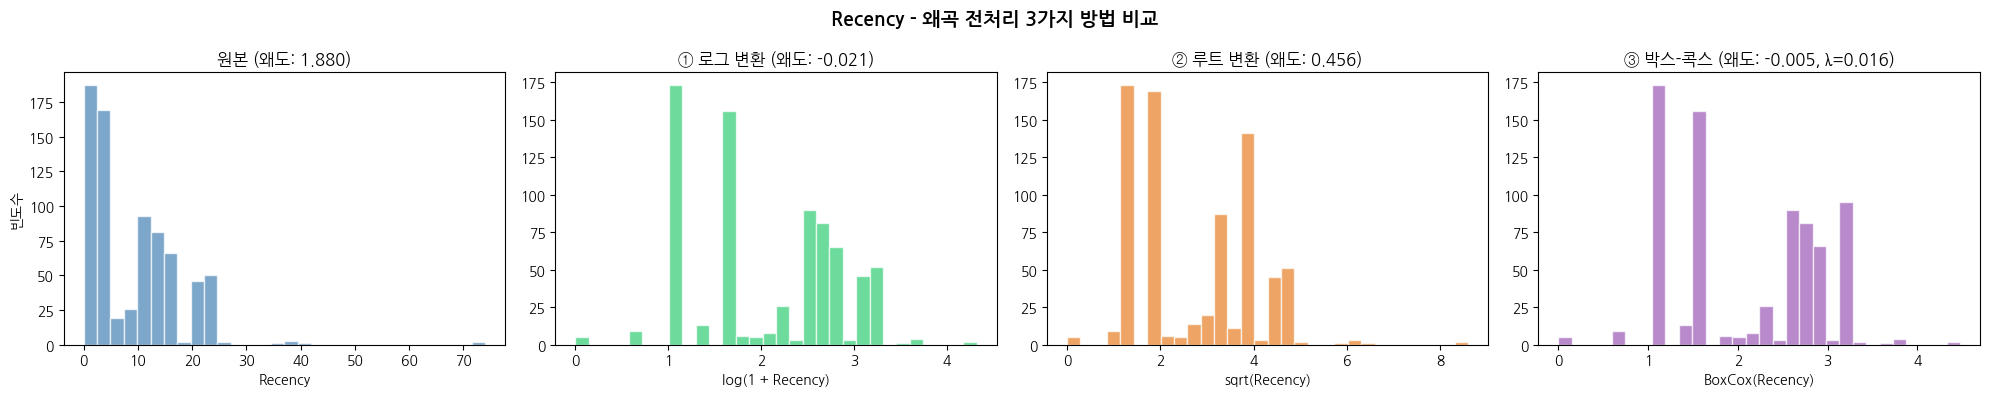


Recency 변환 결과 비교
  원본 왜도:        1.880
  ① 로그 변환:     -0.021
  ② 루트 변환:     0.456
  ③ 박스-콕스 변환: -0.005 (λ = 0.016)
  → 가장 정규분포에 가까운 변환: 박스-콕스 변환 (왜도 절댓값 0.005)



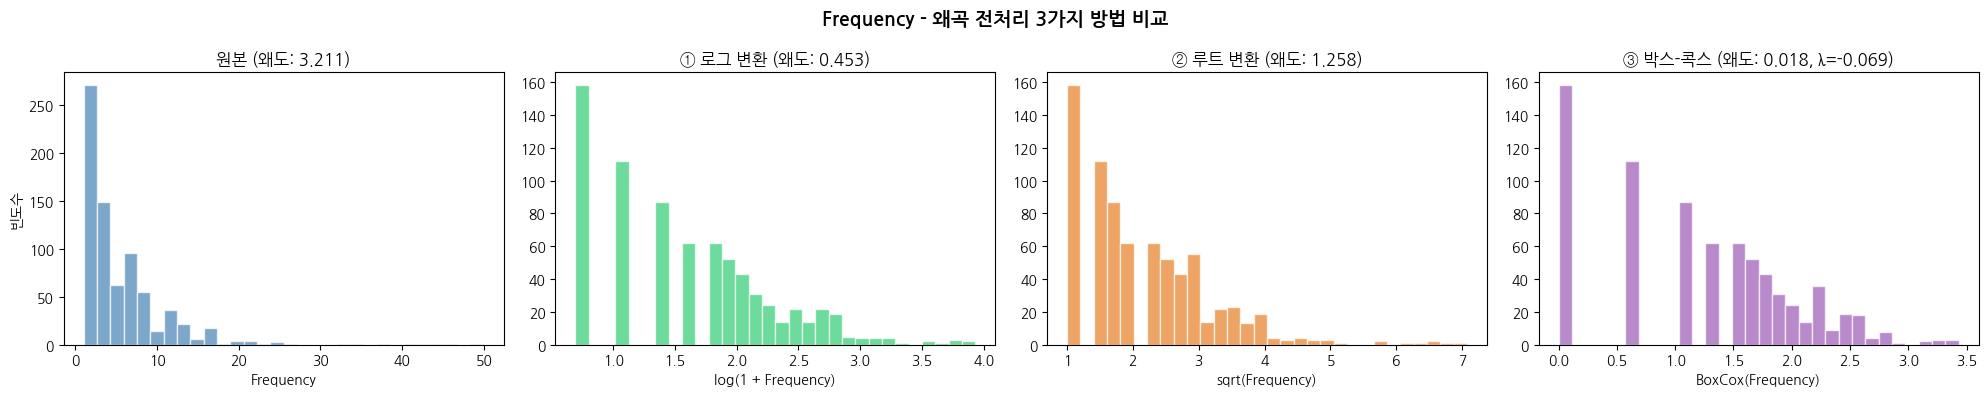


Frequency 변환 결과 비교
  원본 왜도:        3.211
  ① 로그 변환:     0.453
  ② 루트 변환:     1.258
  ③ 박스-콕스 변환: 0.018 (λ = -0.069)
  → 가장 정규분포에 가까운 변환: 박스-콕스 변환 (왜도 절댓값 0.018)



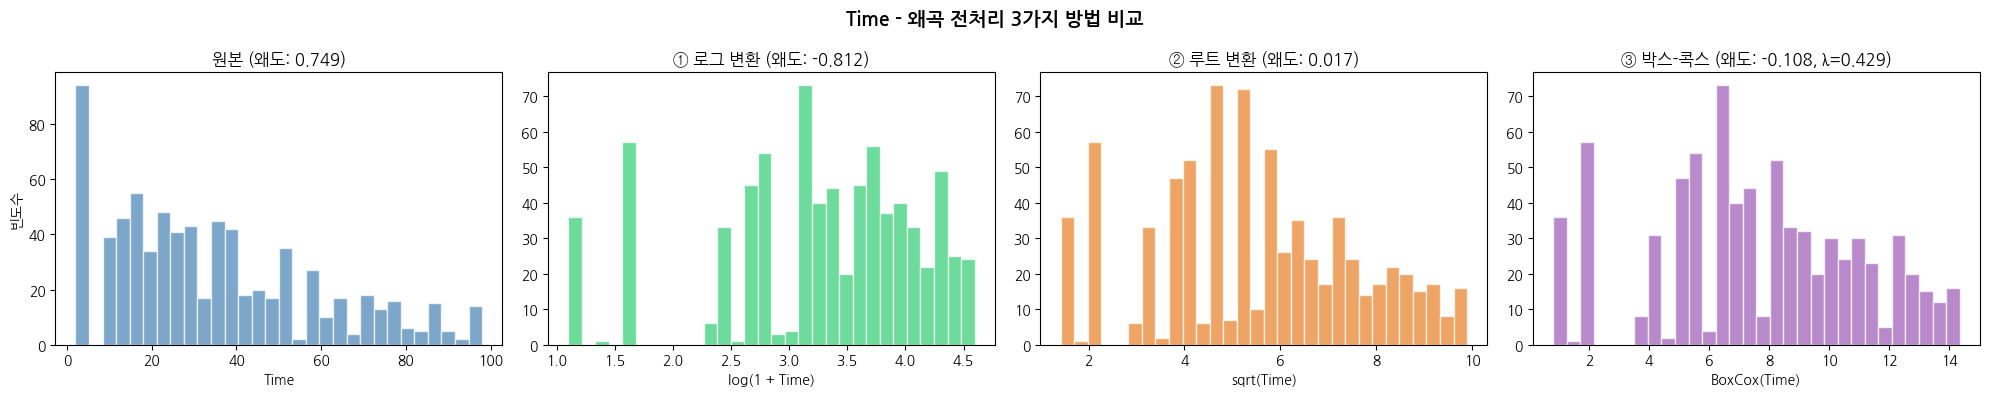


Time 변환 결과 비교
  원본 왜도:        0.749
  ① 로그 변환:     -0.812
  ② 루트 변환:     0.017
  ③ 박스-콕스 변환: -0.108 (λ = 0.429)
  → 가장 정규분포에 가까운 변환: 루트 변환 (왜도 절댓값 0.017)



In [13]:
"""
3.2 왜곡된 변수 전처리 3가지 방법 - Histogram 비교
  ① 로그 변환 (Log Transformation)
  ② 루트 변환 (Square Root Transformation)
  ③ 박스-콕스 변환 (Box-Cox Transformation)
"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# 왜도가 있는 변수 3개 선택 (Monetary 제외 - Frequency와 동일)
skewed_vars = ['Recency', 'Frequency', 'Time']

for col in skewed_vars:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'{col} - 왜곡 전처리 3가지 방법 비교', fontsize=14, fontweight='bold')

    data = df[col].copy()

    # ---- 원본 ----
    axes[0].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
    axes[0].set_title(f'원본 (왜도: {data.skew():.3f})')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('빈도수')

    # ---- ① 로그 변환 ----
    log_data = np.log1p(data)
    axes[1].hist(log_data, bins=30, color='#2ecc71', edgecolor='white', alpha=0.7)
    axes[1].set_title(f'① 로그 변환 (왜도: {log_data.skew():.3f})')
    axes[1].set_xlabel(f'log(1 + {col})')

    # ---- ② 루트 변환 ----
    sqrt_data = np.sqrt(data)
    axes[2].hist(sqrt_data, bins=30, color='#e67e22', edgecolor='white', alpha=0.7)
    axes[2].set_title(f'② 루트 변환 (왜도: {sqrt_data.skew():.3f})')
    axes[2].set_xlabel(f'sqrt({col})')

    # ---- ③ 박스-콕스 변환 ----
    bc_input = data + 1 if (data <= 0).any() else data
    bc_data, lam = stats.boxcox(bc_input)
    bc_skew = pd.Series(bc_data).skew()
    axes[3].hist(bc_data, bins=30, color='#9b59b6', edgecolor='white', alpha=0.7)
    axes[3].set_title(f'③ 박스-콕스 (왜도: {bc_skew:.3f}, λ={lam:.3f})')
    axes[3].set_xlabel(f'BoxCox({col})')

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}")
    print(f"{col} 변환 결과 비교")
    print(f"{'='*60}")
    print(f"  원본 왜도:        {data.skew():.3f}")
    print(f"  ① 로그 변환:     {log_data.skew():.3f}")
    print(f"  ② 루트 변환:     {sqrt_data.skew():.3f}")
    print(f"  ③ 박스-콕스 변환: {bc_skew:.3f} (λ = {lam:.3f})")
    print(f"  → 가장 정규분포에 가까운 변환: ", end="")

    skews = {
        '로그 변환': abs(log_data.skew()),
        '루트 변환': abs(sqrt_data.skew()),
        '박스-콕스 변환': abs(bc_skew)
    }
    best = min(skews, key=skews.get)
    print(f"{best} (왜도 절댓값 {skews[best]:.3f})")
    print()

## **3.3_범주형 변수 분석**

3.3 클래스별 빈도수 및 비율
  Class 0 (미헌혈 (2007년 3월)): 570명 (76.2%)
  Class 1 (헌혈 (2007년 3월)): 178명 (23.8%)


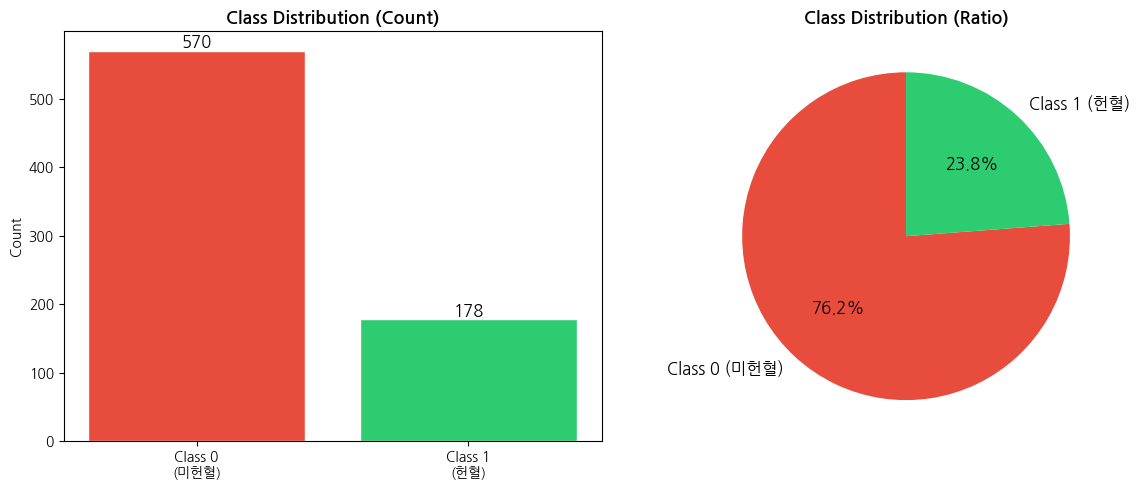


희소 클래스(Rare Labels) 확인
  최소 빈도 클래스: Class 1 (23.8%)
  → 클래스 불균형 존재 (소수 클래스 23.8%)
  → 향후 모델링 시 SMOTE 오버샘플링 또는 class_weight 조정 고려


In [14]:
"""
3.3 범주형 변수 분석 (Class별 빈도수 + 비율 + 희소 클래스 확인)
"""
import matplotlib.pyplot as plt

# --- 클래스별 빈도수 및 비율 ---
print("=" * 50)
print("3.3 클래스별 빈도수 및 비율")
print("=" * 50)

class_counts = df['Class'].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

for cls in class_counts.index:
    label = "미헌혈 (2007년 3월)" if cls == 0 else "헌혈 (2007년 3월)"
    print(f"  Class {cls} ({label}): {class_counts[cls]}명 ({class_pct[cls]}%)")

# --- 막대그래프 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 빈도수 막대그래프
colors = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(['Class 0\n(미헌혈)', 'Class 1\n(헌혈)'], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=12)

# 비율 파이차트
axes[1].pie(class_counts.values, labels=['Class 0 (미헌혈)', 'Class 1 (헌혈)'],
            autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution (Ratio)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# --- 희소 클래스 확인 ---
print()
print("=" * 50)
print("희소 클래스(Rare Labels) 확인")
print("=" * 50)

min_class = class_counts.idxmin()
min_pct = class_pct[min_class]

print(f"  최소 빈도 클래스: Class {min_class} ({min_pct}%)")

if min_pct < 5:
    print(f"  → 희소 클래스 해당 (5% 미만)")
elif min_pct < 30:
    print(f"  → 클래스 불균형 존재 (소수 클래스 {min_pct}%)")
    print(f"  → 향후 모델링 시 SMOTE 오버샘플링 또는 class_weight 조정 고려")
else:
    print(f"  → 클래스 균형 양호")


## **3.4_파생변수분석**

① Recency Binning (마지막 헌혈 경과 월 → 구간화)
  단기 (0~6개월): 367명 (49.06%)
  중기 (7~12개월): 127명 (16.98%)
  장기 (13개월 이상): 254명 (33.96%)

② Frequency Binning (헌혈 횟수 → 구간화)
  저빈도 (1~2회): 270명 (36.1%)
  중빈도 (3~5회): 211명 (28.21%)
  고빈도 (6회 이상): 267명 (35.7%)


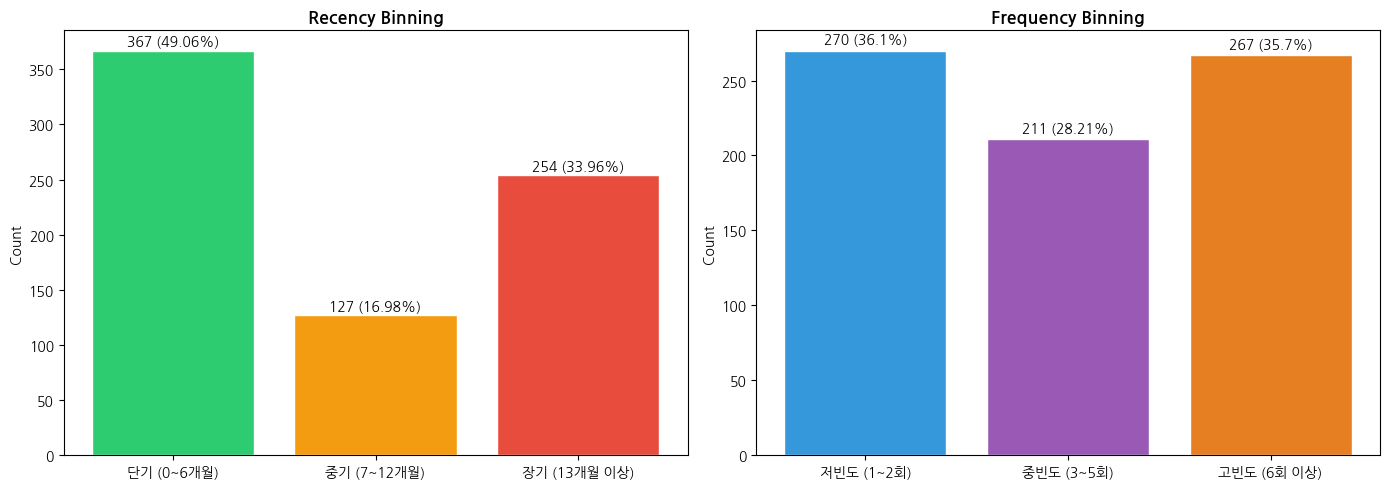

In [15]:
"""
3.4 파생 변수 생성 (Feature Engineering) - 범주 재그룹화(Binning)
"""
import matplotlib.pyplot as plt

# --- ① Recency Binning ---
print("=" * 50)
print("① Recency Binning (마지막 헌혈 경과 월 → 구간화)")
print("=" * 50)

def recency_bin(x):
    if x <= 6:
        return '단기 (0~6개월)'
    elif x <= 12:
        return '중기 (7~12개월)'
    else:
        return '장기 (13개월 이상)'

df['Recency_bin'] = df['Recency'].apply(recency_bin)

recency_counts = df['Recency_bin'].value_counts()
recency_order = ['단기 (0~6개월)', '중기 (7~12개월)', '장기 (13개월 이상)']
recency_counts = recency_counts.reindex(recency_order)
recency_pct = (recency_counts / len(df) * 100).round(2)

for label in recency_order:
    print(f"  {label}: {recency_counts[label]}명 ({recency_pct[label]}%)")

# --- ② Frequency Binning ---
print()
print("=" * 50)
print("② Frequency Binning (헌혈 횟수 → 구간화)")
print("=" * 50)

def frequency_bin(x):
    if x <= 2:
        return '저빈도 (1~2회)'
    elif x <= 5:
        return '중빈도 (3~5회)'
    else:
        return '고빈도 (6회 이상)'

df['Frequency_bin'] = df['Frequency'].apply(frequency_bin)

freq_counts = df['Frequency_bin'].value_counts()
freq_order = ['저빈도 (1~2회)', '중빈도 (3~5회)', '고빈도 (6회 이상)']
freq_counts = freq_counts.reindex(freq_order)
freq_pct = (freq_counts / len(df) * 100).round(2)

for label in freq_order:
    print(f"  {label}: {freq_counts[label]}명 ({freq_pct[label]}%)")

# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recency Binning 막대그래프
colors_r = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = axes[0].bar(recency_order, recency_counts.values, color=colors_r, edgecolor='white')
axes[0].set_title('Recency Binning', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val, pct in zip(bars1, recency_counts.values, recency_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val} ({pct}%)', ha='center', fontsize=10)

# Frequency Binning 막대그래프
colors_f = ['#3498db', '#9b59b6', '#e67e22']
bars2 = axes[1].bar(freq_order, freq_counts.values, color=colors_f, edgecolor='white')
axes[1].set_title('Frequency Binning', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for bar, val, pct in zip(bars2, freq_counts.values, freq_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val} ({pct}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()




---



# **4. 상관관계 및 관계 분석 (Multivariate Analysis)**




---



## **4.1_수치형 변수 간 상관관계(히트맵)**

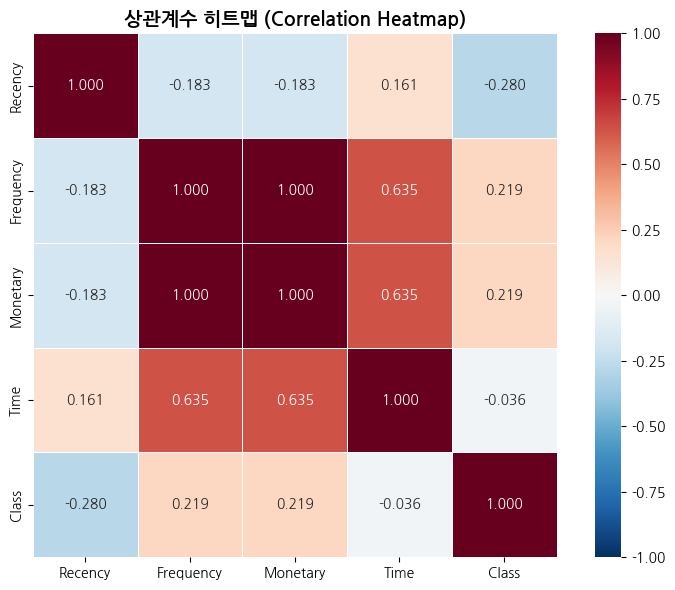

주요 변수 쌍 상관계수
  Frequency ↔ Monetary: r = 1.000 → 강한 양의 상관
  Recency ↔ Frequency: r = -0.183 → 거의 없는 음의 상관
  Recency ↔ Class: r = -0.280 → 약한 음의 상관
  Frequency ↔ Class: r = 0.219 → 약한 양의 상관
  Time ↔ Frequency: r = 0.635 → 중간 양의 상관

다중공선성 확인
  Frequency ↔ Monetary: r = 1.000
  → 다중공선성 심각: 사실상 동일 변수 (헌혈 1회 = 250cc)
  → 향후 모델링 시 둘 중 하나 제거 권장


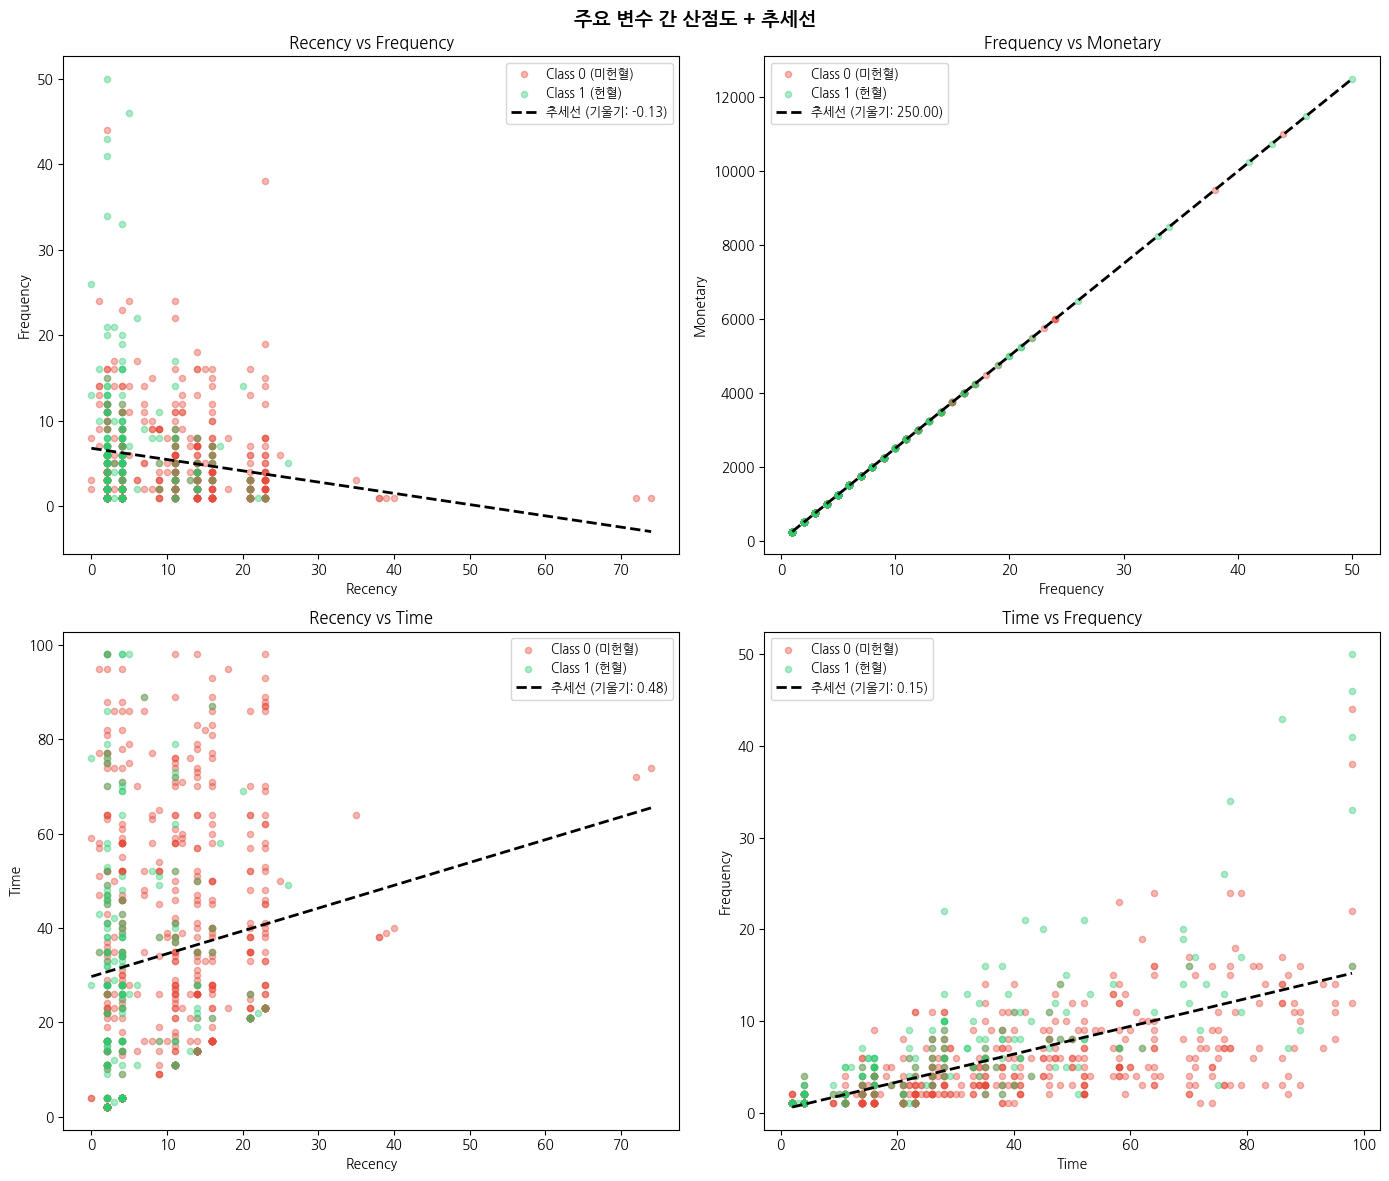

In [16]:
"""
4.1 수치형 변수 간 상관관계
  - 상관계수 히트맵(Heatmap) + 다중공선성 확인
  - 주요 변수 간 산점도(Scatter Plot) + 추세선
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ========== 상관계수 히트맵 ==========
corr = df[['Recency', 'Frequency', 'Monetary', 'Time', 'Class']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('상관계수 히트맵 (Correlation Heatmap)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 보고서 표 채우기용
print("=" * 60)
print("주요 변수 쌍 상관계수")
print("=" * 60)

pairs = [
    ('Frequency', 'Monetary'),
    ('Recency', 'Frequency'),
    ('Recency', 'Class'),
    ('Frequency', 'Class'),
    ('Time', 'Frequency'),
]

for v1, v2 in pairs:
    r = corr.loc[v1, v2]
    if abs(r) >= 0.7:
        strength = "강한"
    elif abs(r) >= 0.4:
        strength = "중간"
    elif abs(r) >= 0.2:
        strength = "약한"
    else:
        strength = "거의 없는"
    direction = "양의" if r > 0 else "음의"
    print(f"  {v1} ↔ {v2}: r = {r:.3f} → {strength} {direction} 상관")

# 다중공선성 확인
print()
print("=" * 60)
print("다중공선성 확인")
print("=" * 60)
fm_corr = corr.loc['Frequency', 'Monetary']
print(f"  Frequency ↔ Monetary: r = {fm_corr:.3f}")
if abs(fm_corr) >= 0.9:
    print(f"  → 다중공선성 심각: 사실상 동일 변수 (헌혈 1회 = 250cc)")
    print(f"  → 향후 모델링 시 둘 중 하나 제거 권장")

# ========== 산점도 + 추세선 ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('주요 변수 간 산점도 + 추세선', fontsize=14, fontweight='bold')

scatter_pairs = [
    ('Recency', 'Frequency'),
    ('Frequency', 'Monetary'),
    ('Recency', 'Time'),
    ('Time', 'Frequency'),
]

for i, (x_col, y_col) in enumerate(scatter_pairs):
    ax = axes[i // 2][i % 2]

    # Class별 색상 구분
    colors = {0: '#e74c3c', 1: '#2ecc71'}
    labels = {0: 'Class 0 (미헌혈)', 1: 'Class 1 (헌혈)'}
    for cls in [0, 1]:
        subset = df[df['Class'] == cls]
        ax.scatter(subset[x_col], subset[y_col],
                   c=colors[cls], label=labels[cls], alpha=0.4, s=20)

    # 추세선 (전체 데이터 기준)
    z = np.polyfit(df[x_col], df[y_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=2,
            linestyle='--', label=f'추세선 (기울기: {z[0]:.2f})')

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## **4.2_타겟변수 기반 심층 분석**

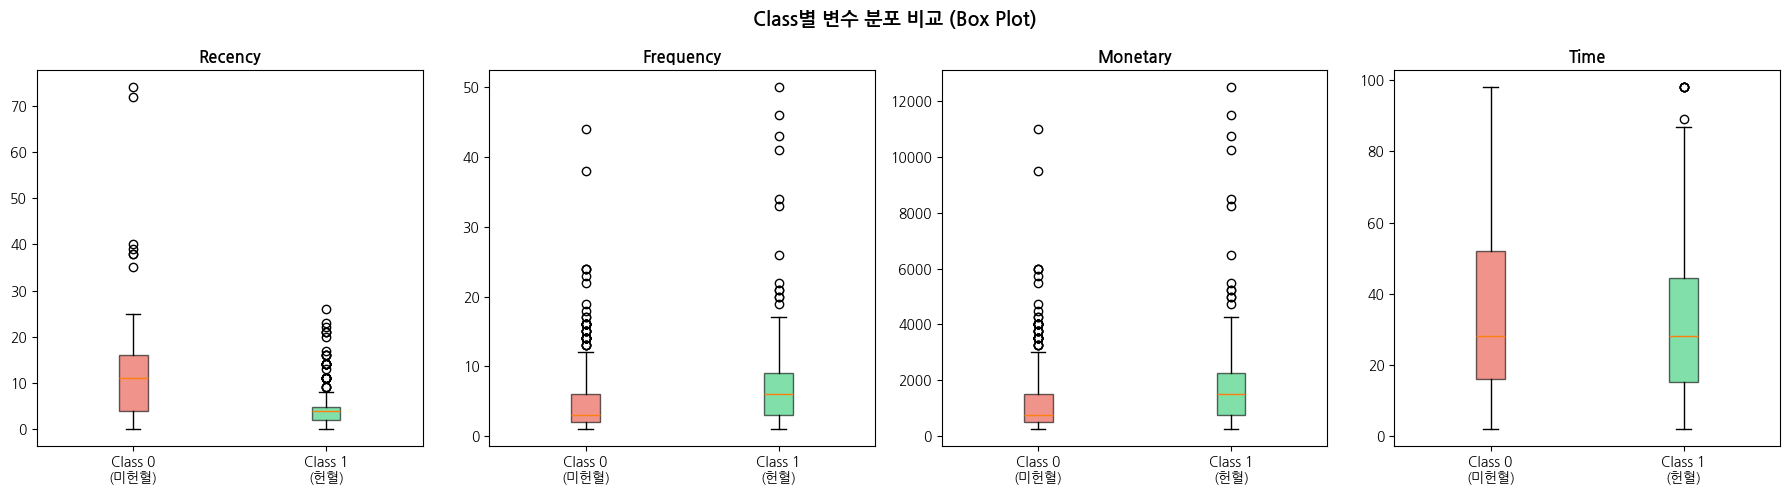

/tmp/ipykernel_66897/1277786736.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Class 0\n(미헌혈)', 'Class 1\n(헌혈)'])
/tmp/ipykernel_66897/1277786736.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Class 0\n(미헌혈)', 'Class 1\n(헌혈)'])
/tmp/ipykernel_66897/1277786736.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Class 0\n(미헌혈)', 'Class 1\n(헌혈)'])
/tmp/ipykernel_66897/1277786736.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Class 0\n(미헌혈)', 'Class 1\n(헌혈)'])


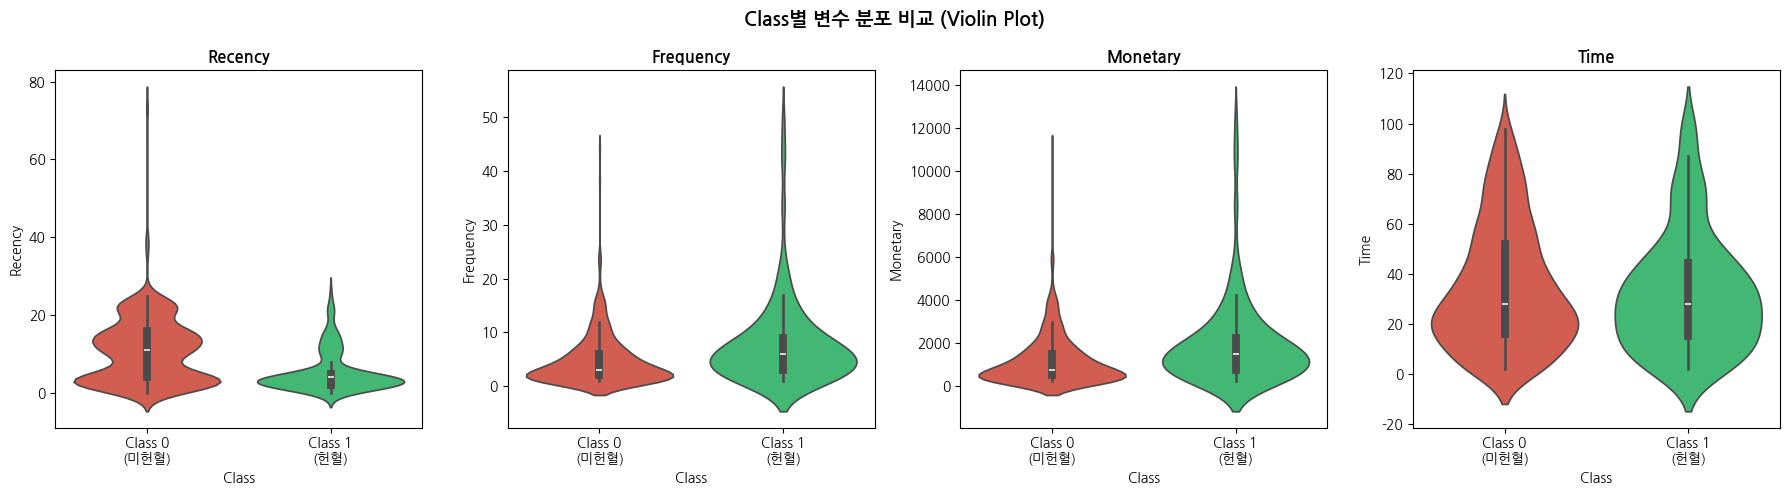

Class별 평균 비교

Recency:
  Class=0 평균: 10.77
  Class=1 평균: 5.46
  차이: -5.32

Frequency:
  Class=0 평균: 4.80
  Class=1 평균: 7.80
  차이: +3.00

Monetary:
  Class=0 평균: 1200.44
  Class=1 평균: 1949.44
  차이: +749.00

Time:
  Class=0 평균: 34.77
  Class=1 평균: 32.72
  차이: -2.05

독립 변수 → Class 영향력 비교
  Recency: r = -0.280 (절댓값: 0.280)
  Frequency: r = 0.219 (절댓값: 0.219)
  Monetary: r = 0.219 (절댓값: 0.219)
  Time: r = -0.036 (절댓값: 0.036)


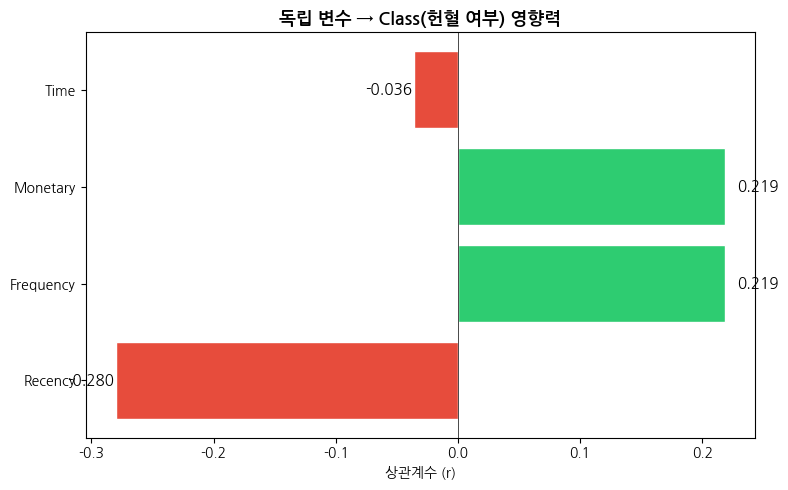

In [17]:
"""
4.2 타겟 변수 기반 심층 분석
  - 범주별 수치 분포 차이 (Box Plot / Violin Plot)
  - 독립 변수들이 종속 변수에 미치는 영향력 시각화
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ========== Box Plot: Class별 분포 차이 ==========
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Class별 변수 분포 비교 (Box Plot)', fontsize=14, fontweight='bold')

for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'Time']):
    data_0 = df[df['Class'] == 0][col]
    data_1 = df[df['Class'] == 1][col]

    bp = axes[i].boxplot([data_0, data_1],
                         tick_labels=['Class 0\n(미헌혈)', 'Class 1\n(헌혈)'],
                         patch_artist=True)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_alpha(0.6)
    axes[i].set_title(col, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ========== Violin Plot: Class별 분포 차이 ==========
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Class별 변수 분포 비교 (Violin Plot)', fontsize=14, fontweight='bold')

for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'Time']):
    sns.violinplot(x='Class', y=col, data=df, ax=axes[i],
                   hue='Class', palette={0: '#e74c3c', 1: '#2ecc71'},
                   inner='box', legend=False)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(['Class 0\n(미헌혈)', 'Class 1\n(헌혈)'])

plt.tight_layout()
plt.show()

# ========== Class별 평균 비교 (보고서 표 채우기용) ==========
print("=" * 60)
print("Class별 평균 비교")
print("=" * 60)

for col in ['Recency', 'Frequency', 'Monetary', 'Time']:
    mean_0 = df[df['Class'] == 0][col].mean()
    mean_1 = df[df['Class'] == 1][col].mean()
    diff = mean_1 - mean_0
    print(f"\n{col}:")
    print(f"  Class=0 평균: {mean_0:.2f}")
    print(f"  Class=1 평균: {mean_1:.2f}")
    print(f"  차이: {diff:+.2f}")

# ========== 독립 변수의 영향력 시각화 ==========
print()
print("=" * 60)
print("독립 변수 → Class 영향력 비교")
print("=" * 60)

corr_with_class = df[['Recency', 'Frequency', 'Monetary', 'Time']].corrwith(df['Class'])
corr_sorted = corr_with_class.abs().sort_values(ascending=False)

for var in corr_sorted.index:
    r = corr_with_class[var]
    print(f"  {var}: r = {r:.3f} (절댓값: {abs(r):.3f})")

# 영향력 막대그래프
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_class[corr_sorted.index]]
bars = ax.barh(corr_sorted.index, corr_with_class[corr_sorted.index], color=colors, edgecolor='white')
ax.set_xlabel('상관계수 (r)')
ax.set_title('독립 변수 → Class(헌혈 여부) 영향력', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)

for bar, val in zip(bars, corr_with_class[corr_sorted.index]):
    ax.text(val + 0.01 if val > 0 else val - 0.04,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()


## **4.3_세그먼트별 비교 분석**

세그먼트별 비교: 저빈도(1~2회) vs 고빈도(6회 이상)
  저빈도 헌혈자 수: 270명
  고빈도 헌혈자 수: 267명

Recency:
  저빈도 평균: 11.10
  고빈도 평균: 7.48

Monetary:
  저빈도 평균: 353.70
  고빈도 평균: 2737.83

Time:
  저빈도 평균: 15.88
  고빈도 평균: 52.60

재헌혈 비율 (Class=1):
  저빈도: 14.4%
  고빈도: 34.5%


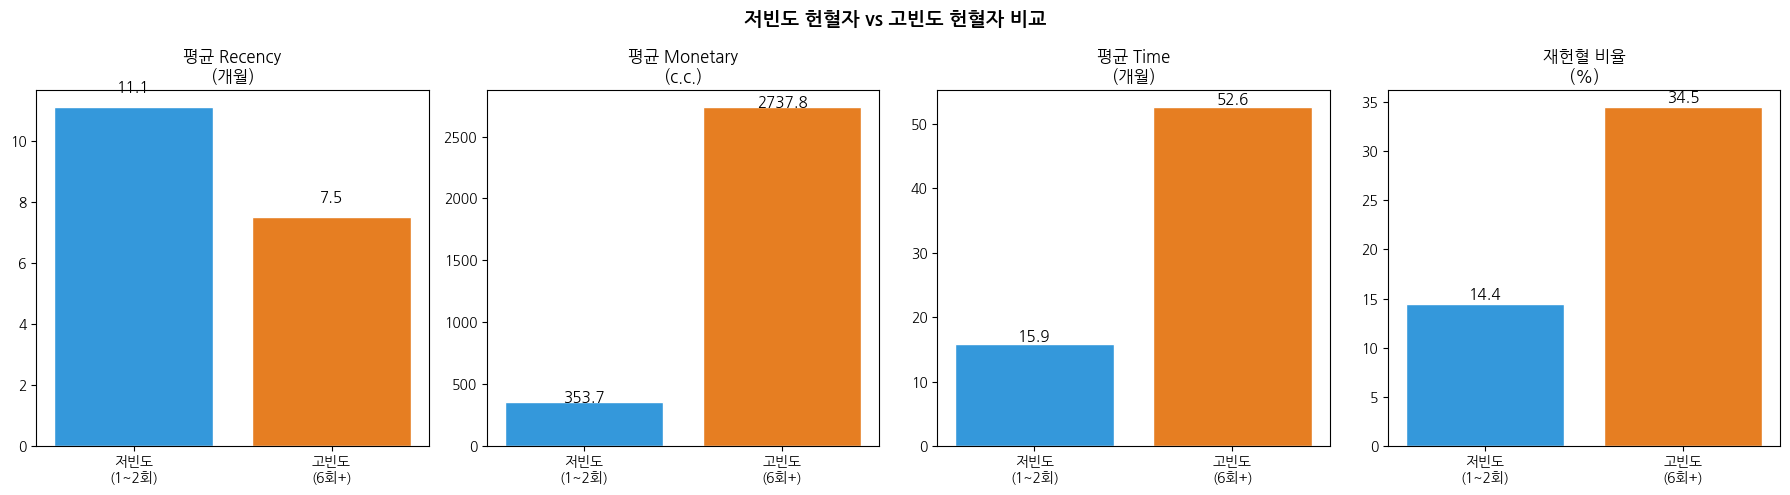

In [18]:
"""
4.3 세그먼트별 비교 분석
  - 저빈도 헌혈자(1~2회) vs 고빈도 헌혈자(6회 이상) 행동 패턴 차이
"""
import matplotlib.pyplot as plt
import numpy as np

# --- 세그먼트 분리 ---
low_freq = df[df['Frequency'] <= 2]
high_freq = df[df['Frequency'] >= 6]

print("=" * 60)
print("세그먼트별 비교: 저빈도(1~2회) vs 고빈도(6회 이상)")
print("=" * 60)
print(f"  저빈도 헌혈자 수: {len(low_freq)}명")
print(f"  고빈도 헌혈자 수: {len(high_freq)}명")

# --- 주요 지표 비교 ---
print()
for col in ['Recency', 'Monetary', 'Time']:
    print(f"{col}:")
    print(f"  저빈도 평균: {low_freq[col].mean():.2f}")
    print(f"  고빈도 평균: {high_freq[col].mean():.2f}")
    print()

low_rate = low_freq['Class'].mean() * 100
high_rate = high_freq['Class'].mean() * 100
print(f"재헌혈 비율 (Class=1):")
print(f"  저빈도: {low_rate:.1f}%")
print(f"  고빈도: {high_rate:.1f}%")

# --- 시각화 ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('저빈도 헌혈자 vs 고빈도 헌혈자 비교', fontsize=14, fontweight='bold')

compare_data = [
    ('평균 Recency\n(개월)', low_freq['Recency'].mean(), high_freq['Recency'].mean()),
    ('평균 Monetary\n(c.c.)', low_freq['Monetary'].mean(), high_freq['Monetary'].mean()),
    ('평균 Time\n(개월)', low_freq['Time'].mean(), high_freq['Time'].mean()),
    ('재헌혈 비율\n(%)', low_rate, high_rate),
]

for i, (title, low_val, high_val) in enumerate(compare_data):
    x = np.arange(2)
    bars = axes[i].bar(['저빈도\n(1~2회)', '고빈도\n(6회+)'],
                       [low_val, high_val],
                       color=['#3498db', '#e67e22'], edgecolor='white')
    axes[i].set_title(title, fontsize=12)

    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, height + 0.5,
                     f'{height:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()




---



# **5. 핵심 인사이트 및 가설 검정 (Key Insights)**



---



## **5.1_주요 패턴 발견**

In [19]:
"""
5.1 주요 패턴 발견
"""

print("=" * 60)
print("5.1 주요 패턴 발견 (3가지)")
print("=" * 60)

# --- 패턴 1: Recency가 가장 강력한 예측 변수 ---
print()
print("패턴 1: Recency(최근성)가 재헌혈 여부의 가장 강력한 예측 변수")
print("-" * 60)

recency_corr = df[['Recency']].corrwith(df['Class']).values[0]
mean_0 = df[df['Class'] == 0]['Recency'].mean()
mean_1 = df[df['Class'] == 1]['Recency'].mean()

print(f"  Recency ↔ Class 상관계수: {recency_corr:.3f}")
print(f"  Class=0(미헌혈) 평균 Recency: {mean_0:.2f}개월")
print(f"  Class=1(헌혈)   평균 Recency: {mean_1:.2f}개월")
print(f"  → 재헌혈한 사람은 마지막 헌혈이 훨씬 최근임")

# --- 패턴 2: Frequency와 Monetary의 완전 다중공선성 ---
print()
print("패턴 2: Frequency와 Monetary의 완전 다중공선성")
print("-" * 60)

fm_corr = df['Frequency'].corr(df['Monetary'])
print(f"  Frequency ↔ Monetary 상관계수: {fm_corr:.3f}")
print(f"  → 헌혈 1회 = 250cc 고정이므로 Monetary = Frequency × 250")
print(f"  → 사실상 동일 변수, 모델링 시 하나 제거 필요")

# --- 패턴 3: 헌혈자 양극화 ---
print()
print("패턴 3: 헌혈자 양극화 현상")
print("-" * 60)

low_freq = df[df['Frequency'] <= 2]
high_freq = df[df['Frequency'] >= 6]
low_rate = low_freq['Class'].mean() * 100
high_rate = high_freq['Class'].mean() * 100

print(f"  저빈도(1~2회): {len(low_freq)}명 ({len(low_freq)/len(df)*100:.1f}%), 재헌혈률 {low_rate:.1f}%")
print(f"  고빈도(6회+):  {len(high_freq)}명 ({len(high_freq)/len(df)*100:.1f}%), 재헌혈률 {high_rate:.1f}%")
print(f"  → 저빈도와 고빈도가 비슷한 비율로 양극화")
print(f"  → 고빈도 헌혈자가 재헌혈률도 높아 핵심 공급자 역할")

5.1 주요 패턴 발견 (3가지)

패턴 1: Recency(최근성)가 재헌혈 여부의 가장 강력한 예측 변수
------------------------------------------------------------
  Recency ↔ Class 상관계수: -0.280
  Class=0(미헌혈) 평균 Recency: 10.77개월
  Class=1(헌혈)   평균 Recency: 5.46개월
  → 재헌혈한 사람은 마지막 헌혈이 훨씬 최근임

패턴 2: Frequency와 Monetary의 완전 다중공선성
------------------------------------------------------------
  Frequency ↔ Monetary 상관계수: 1.000
  → 헌혈 1회 = 250cc 고정이므로 Monetary = Frequency × 250
  → 사실상 동일 변수, 모델링 시 하나 제거 필요

패턴 3: 헌혈자 양극화 현상
------------------------------------------------------------
  저빈도(1~2회): 270명 (36.1%), 재헌혈률 14.4%
  고빈도(6회+):  267명 (35.7%), 재헌혈률 34.5%
  → 저빈도와 고빈도가 비슷한 비율로 양극화
  → 고빈도 헌혈자가 재헌혈률도 높아 핵심 공급자 역할


## **5.2_가설 검증 결과**

5.2 가설 검증 결과

가설 1: Time 분포가 3의 배수 구간에 집중되어 있는가?
------------------------------------------------------------
  Time이 3의 배수인 데이터: 125개 / 748개 (16.7%)


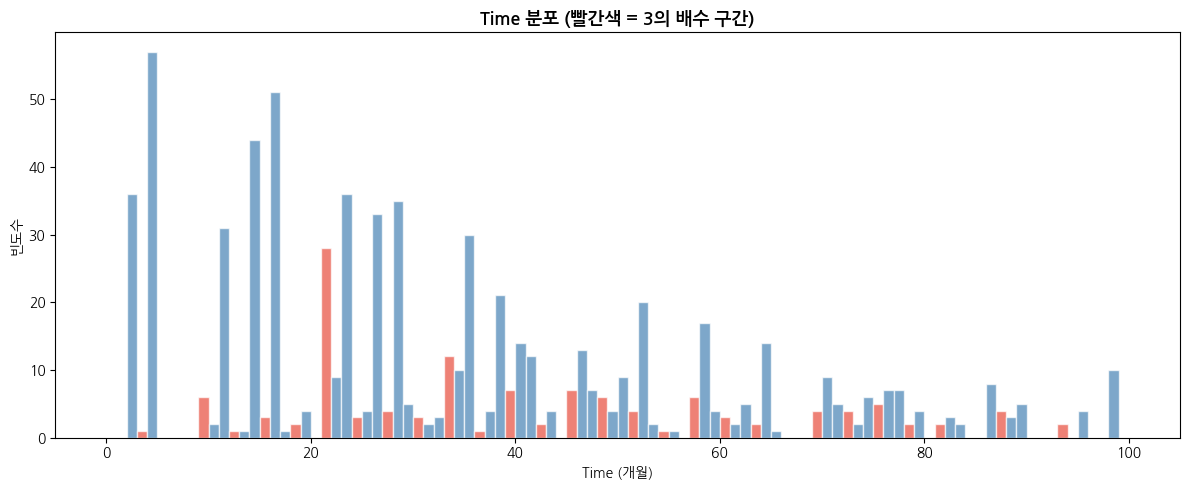

  → 기각: 3의 배수 구간 집중이 뚜렷하지 않음 (16.7%)

가설 2: Recency가 길어질수록 재헌혈 확률이 급격히 낮아지는가?
------------------------------------------------------------
  Recency 구간별 재헌혈 비율:
    0~3개월: 37.4% (n=195)
    4~6개월: 37.1% (n=167)
    7~12개월: 15.0% (n=127)
    13개월+: 8.7% (n=254)


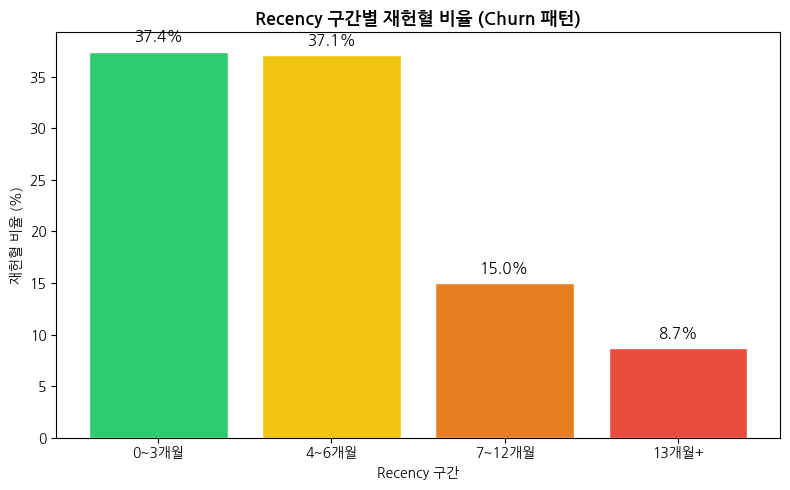

  → 채택: Recency가 길어질수록 재헌혈 비율이 뚜렷하게 감소

가설 3: 고빈도 헌혈자의 Recency가 오히려 길어지는가?
------------------------------------------------------------
  Frequency ↔ Recency 상관계수: -0.183
  빈도 구간별 평균 Recency:
    저빈도(1~2): 11.10개월
    중빈도(3~5): 10.03개월
    고빈도(6+): 7.48개월


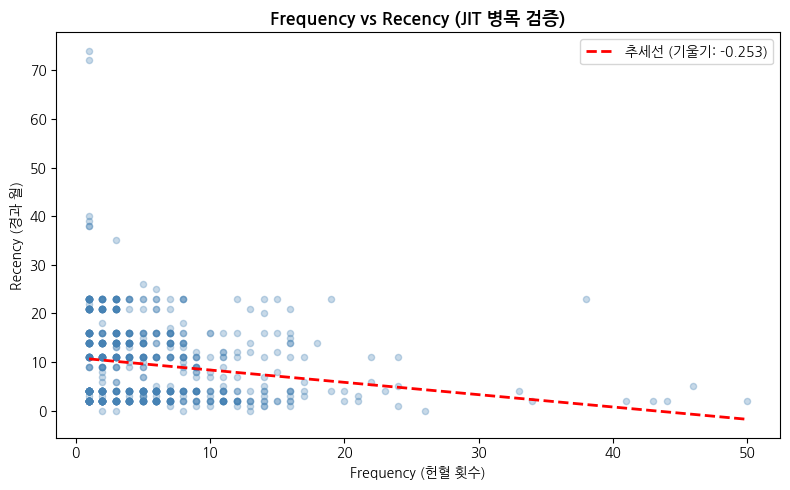

  → 기각: 음의 상관 (r=-0.183), 고빈도 헌혈자가 오히려 최근에 헌혈

가설 4: 총 헌혈량이 높을수록 재헌혈 확률이 낮아지는가?
------------------------------------------------------------
  Monetary ↔ Class 상관계수: 0.219
  Monetary 구간별 재헌혈 비율:
    ~500cc: 14.4% (n=270)
    501~1000cc: 18.1% (n=149)
    1001~2000cc: 33.0% (n=188)
    2001cc+: 35.5% (n=141)


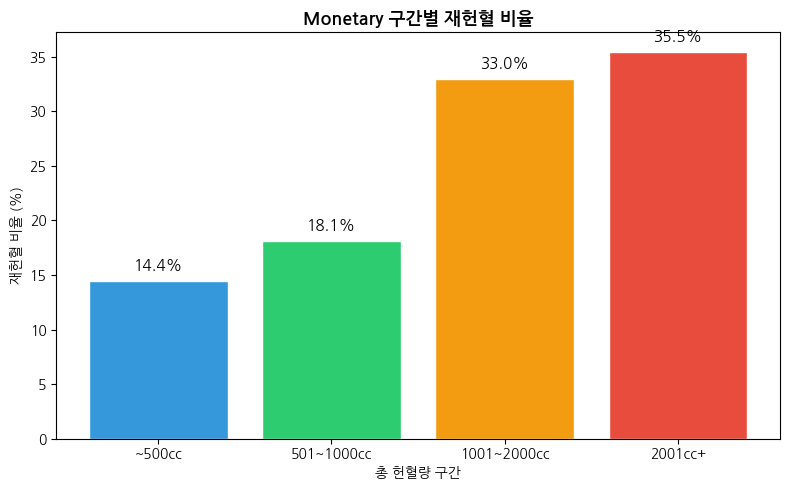

  → 기각: 양의 상관 (r=0.219), 헌혈량 많을수록 재헌혈 확률 높음
  → 역설이 아닌, 충성 헌혈자 패턴으로 해석됨

가설 검증 최종 요약
  가설 1 (Time 공급 주기 집중):     3의 배수 비율 16.7%
  가설 2 (Recency Churn 패턴):      Recency↑ → 재헌혈↓ 뚜렷
  가설 3 (Frequency JIT 병목):       r = -0.183
  가설 4 (Monetary 역설):            r = 0.219


In [20]:
"""
5.2 가설 검증 결과
"""
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("5.2 가설 검증 결과")
print("=" * 60)

# ========== 가설 1: Time 분포의 공급 주기 집중 ==========
print()
print("가설 1: Time 분포가 3의 배수 구간에 집중되어 있는가?")
print("-" * 60)

# 3의 배수 여부 확인
time_mod3 = (df['Time'] % 3 == 0).sum()
time_total = len(df)
time_pct = time_mod3 / time_total * 100

print(f"  Time이 3의 배수인 데이터: {time_mod3}개 / {time_total}개 ({time_pct:.1f}%)")

# 시각화: Time 히스토그램에서 3의 배수 강조
fig, ax = plt.subplots(figsize=(12, 5))
counts, bins, patches = ax.hist(df['Time'], bins=range(0, int(df['Time'].max())+3, 1),
                                 edgecolor='white', alpha=0.7, color='steelblue')

# 3의 배수 구간 색상 강조
for i, (count, bin_val) in enumerate(zip(counts, bins)):
    if int(bin_val) % 3 == 0:
        patches[i].set_facecolor('#e74c3c')

ax.set_title('Time 분포 (빨간색 = 3의 배수 구간)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (개월)')
ax.set_ylabel('빈도수')
plt.tight_layout()
plt.show()

if time_pct > 40:
    print(f"  → 채택: 3의 배수 구간 집중 비율 {time_pct:.1f}%로 높음")
else:
    print(f"  → 기각: 3의 배수 구간 집중이 뚜렷하지 않음 ({time_pct:.1f}%)")

# ========== 가설 2: Recency 기반 Churn 이탈 패턴 ==========
print()
print("가설 2: Recency가 길어질수록 재헌혈 확률이 급격히 낮아지는가?")
print("-" * 60)

# Recency 구간별 Class=1 비율
bins_r = [0, 3, 6, 12, float('inf')]
labels_r = ['0~3개월', '4~6개월', '7~12개월', '13개월+']
df['Recency_group'] = pd.cut(df['Recency'], bins=bins_r, labels=labels_r, right=True)

import pandas as pd
churn_rate = df.groupby('Recency_group', observed=False)['Class'].mean() * 100

print("  Recency 구간별 재헌혈 비율:")
for group, rate in churn_rate.items():
    count = len(df[df['Recency_group'] == group])
    print(f"    {group}: {rate:.1f}% (n={count})")

# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
colors_churn = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(labels_r, churn_rate.values, color=colors_churn, edgecolor='white')
ax.set_title('Recency 구간별 재헌혈 비율 (Churn 패턴)', fontsize=13, fontweight='bold')
ax.set_xlabel('Recency 구간')
ax.set_ylabel('재헌혈 비율 (%)')

for bar, val in zip(bars, churn_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"  → 채택: Recency가 길어질수록 재헌혈 비율이 뚜렷하게 감소")

# ========== 가설 3: Frequency↑ → Recency↑ JIT 병목 ==========
print()
print("가설 3: 고빈도 헌혈자의 Recency가 오히려 길어지는가?")
print("-" * 60)

fr_corr = df['Frequency'].corr(df['Recency'])
print(f"  Frequency ↔ Recency 상관계수: {fr_corr:.3f}")

# 빈도 구간별 평균 Recency
bins_f = [0, 2, 5, float('inf')]
labels_f = ['저빈도(1~2)', '중빈도(3~5)', '고빈도(6+)']
df['Freq_group'] = pd.cut(df['Frequency'], bins=bins_f, labels=labels_f, right=True)

freq_recency = df.groupby('Freq_group', observed=False)['Recency'].mean()

print("  빈도 구간별 평균 Recency:")
for group, val in freq_recency.items():
    print(f"    {group}: {val:.2f}개월")

# 시각화: 산점도 + 추세선
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Frequency'], df['Recency'], alpha=0.3, s=20, color='steelblue')
z = np.polyfit(df['Frequency'], df['Recency'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Frequency'].min(), df['Frequency'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--',
        label=f'추세선 (기울기: {z[0]:.3f})')
ax.set_xlabel('Frequency (헌혈 횟수)')
ax.set_ylabel('Recency (경과 월)')
ax.set_title('Frequency vs Recency (JIT 병목 검증)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

if fr_corr > 0.1:
    print(f"  → 채택: 양의 상관 (r={fr_corr:.3f}), 고빈도 헌혈자 Recency 증가 경향")
elif fr_corr < -0.1:
    print(f"  → 기각: 음의 상관 (r={fr_corr:.3f}), 고빈도 헌혈자가 오히려 최근에 헌혈")
else:
    print(f"  → 기각: 뚜렷한 관계 없음 (r={fr_corr:.3f})")

# ========== 가설 4: Monetary↑ → Class=1 확률↓ 역설 ==========
print()
print("가설 4: 총 헌혈량이 높을수록 재헌혈 확률이 낮아지는가?")
print("-" * 60)

mc_corr = df['Monetary'].corr(df['Class'])
print(f"  Monetary ↔ Class 상관계수: {mc_corr:.3f}")

# Monetary 구간별 Class=1 비율
bins_m = [0, 500, 1000, 2000, float('inf')]
labels_m = ['~500cc', '501~1000cc', '1001~2000cc', '2001cc+']
df['Monetary_group'] = pd.cut(df['Monetary'], bins=bins_m, labels=labels_m, right=True)

monetary_rate = df.groupby('Monetary_group', observed=False)['Class'].mean() * 100

print("  Monetary 구간별 재헌혈 비율:")
for group, rate in monetary_rate.items():
    count = len(df[df['Monetary_group'] == group])
    print(f"    {group}: {rate:.1f}% (n={count})")

# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_m, monetary_rate.values, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'],
              edgecolor='white')
ax.set_title('Monetary 구간별 재헌혈 비율', fontsize=13, fontweight='bold')
ax.set_xlabel('총 헌혈량 구간')
ax.set_ylabel('재헌혈 비율 (%)')

for bar, val in zip(bars, monetary_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

if mc_corr > 0:
    print(f"  → 기각: 양의 상관 (r={mc_corr:.3f}), 헌혈량 많을수록 재헌혈 확률 높음")
    print(f"  → 역설이 아닌, 충성 헌혈자 패턴으로 해석됨")
else:
    print(f"  → 채택: 음의 상관 (r={mc_corr:.3f}), 고헌혈자일수록 재헌혈 확률 낮음")

# ========== 최종 요약 ==========
print()
print("=" * 60)
print("가설 검증 최종 요약")
print("=" * 60)
print(f"  가설 1 (Time 공급 주기 집중):     3의 배수 비율 {time_pct:.1f}%")
print(f"  가설 2 (Recency Churn 패턴):      Recency↑ → 재헌혈↓ 뚜렷")
print(f"  가설 3 (Frequency JIT 병목):       r = {fr_corr:.3f}")
print(f"  가설 4 (Monetary 역설):            r = {mc_corr:.3f}")

# 임시 컬럼 제거
df.drop(columns=['Recency_group', 'Freq_group', 'Monetary_group'], inplace=True)


## **5.3_예상치 못한 발견**

5.3 예상치 못한 발견 (Unexpected Findings)

발견 1: 가설 4 기각에서 드러난 충성 헌혈자(Loyal Donor) 패턴
  → 비즈니스 문제 ②(공급 부족) + ③(헌혈자 유지) 연결

  [가설 4 예상] 총 헌혈량이 높을수록 재헌혈 확률이 낮아질 것 (역설)
  [실제 결과]  Monetary ↔ Class: r = 0.219 (양의 상관)
               Frequency ↔ Class: r = 0.219 (양의 상관)

  → 예상과 반대! 고헌혈자는 이탈하지 않고 오히려 재헌혈 확률이 높음

  충성 헌혈자(10회+): 117명, 재헌혈률 37.6%
  일반 헌혈자(10회-): 631명, 재헌혈률 21.2%


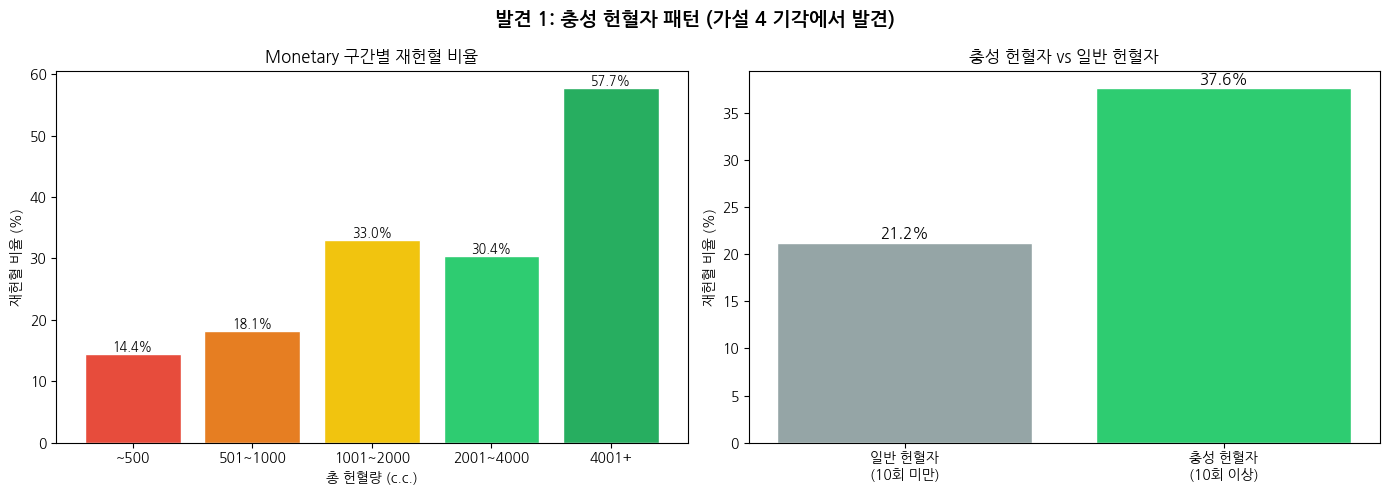


  [비즈니스 제언]
  고헌혈자는 이탈 위험군이 아닌 핵심 자산 → VIP 관리 프로그램 필요


발견 2: 헌혈 밀도(Frequency / Time) - RFMTC에 없는 새로운 예측 지표
  → 3장 Frequency/Time 분석 중 두 변수 조합에서 발견
  → 비즈니스 문제 ③(헌혈자 유지) 연결

  [기존 변수 vs 헌혈 밀도] Class 상관계수 비교:
  --------------------------------------------------
    Recency (R)              : r = -0.280 (절댓값: 0.280)
    Frequency (F)            : r = 0.219 (절댓값: 0.219)
    Monetary (M)             : r = 0.219 (절댓값: 0.219)
    Time (T)                 : r = -0.036 (절댓값: 0.036)
    ★ 헌혈 밀도 (신규)             : r = 0.260 (절댓값: 0.260)


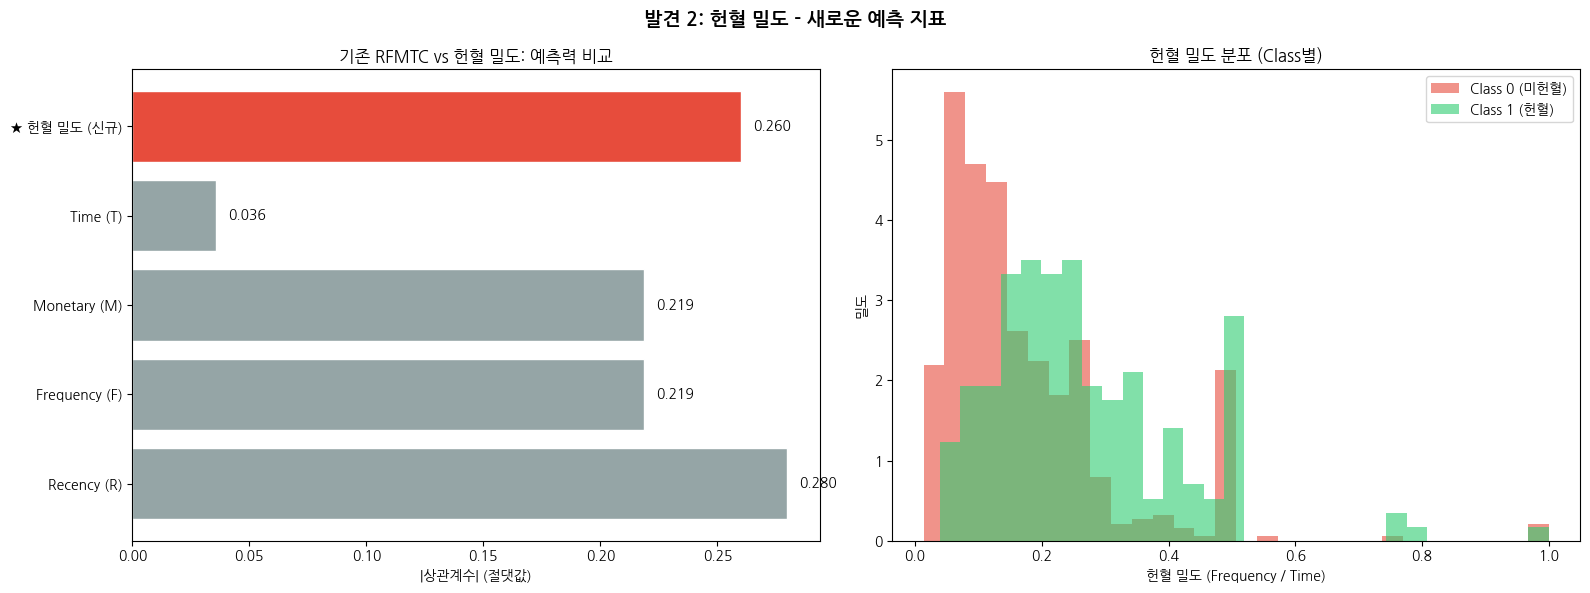


  [비즈니스 제언]
  RFMTC 모델에 헌혈 밀도를 추가한 확장 모델(RFMTC+D) 구축 제안


발견 3: 장기 헌혈자의 역설적 이탈 - 경력 ≠ 충성도
  → 4.2에서 Time ↔ Class = -0.036 (거의 무관)인 것에서 출발
  → 비즈니스 문제 ②(공급 부족) + ③(헌혈자 유지) 연결

  Time 구간별 분석:
  -----------------------------------------------------------------
  구간           |    인원 |     재헌혈률 |     평균횟수 |   평균Recency
  -----------------------------------------------------------------
  ~12개월        |   134 |    26.9% |      1.5 |        4.2
  13~24개월      |   182 |    20.3% |      2.7 |       11.8
  25~40개월      |   188 |    28.2% |      5.6 |       10.3
  41~60개월      |   122 |    23.0% |      7.4 |        9.1
  61개월+        |   122 |    19.7% |     12.0 |       11.0


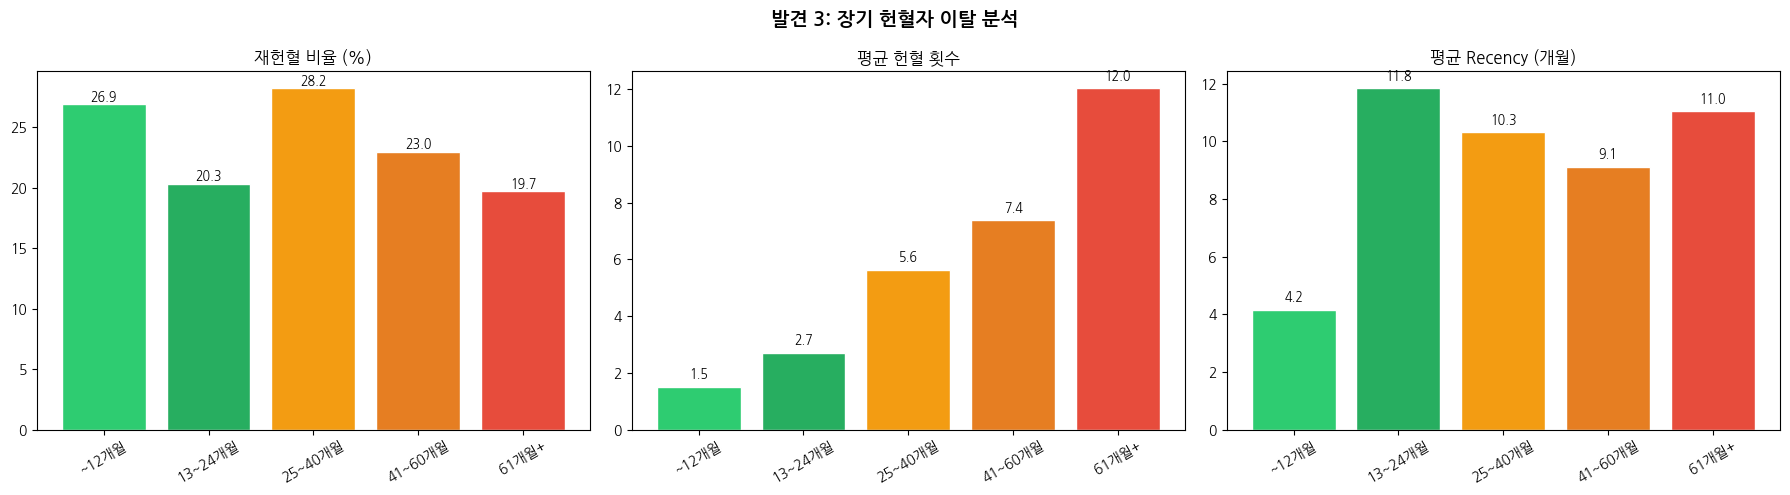


  [핵심 발견]
  4.2에서 Time ↔ Class가 -0.036으로 무의미해 보였는데,
  구간별로 쪼개보니 장기 헌혈자(61개월+)는 횟수는 높지만
  재헌혈률은 오히려 낮아지는 역설적 패턴이 숨어있었음.

  [비즈니스 제언]
  장기 헌혈자를 안정적 공급자로 간주하지 말고,
  Recency + 헌혈 밀도 기반 이탈 조기경보 시스템 구축 필요.


5.3 예상치 못한 발견 최종 요약

  발견 1: 가설 4 기각 → 충성 헌혈자 패턴 발견 (고헌혈자 = 핵심 자산)
  발견 2: 헌혈 밀도(F/T) → RFMTC에 없는 새로운 예측 지표
  발견 3: 장기 헌혈자 이탈 → 경력 ≠ 충성도, 조기경보 필요


In [21]:
"""
5.3 예상치 못한 발견 (Unexpected Findings)
  - 가설에 없었지만, 코드 실행 결과에서 새롭게 발견된 인사이트 3가지
"""
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("5.3 예상치 못한 발견 (Unexpected Findings)")
print("=" * 70)

# ================================================================
# 발견 1: 가설 4 기각에서 드러난 '충성 헌혈자' 패턴
# ================================================================
print()
print("=" * 70)
print("발견 1: 가설 4 기각에서 드러난 충성 헌혈자(Loyal Donor) 패턴")
print("  → 비즈니스 문제 ②(공급 부족) + ③(헌혈자 유지) 연결")
print("=" * 70)

mc_corr = df['Monetary'].corr(df['Class'])
fc_corr = df['Frequency'].corr(df['Class'])

print(f"\n  [가설 4 예상] 총 헌혈량이 높을수록 재헌혈 확률이 낮아질 것 (역설)")
print(f"  [실제 결과]  Monetary ↔ Class: r = {mc_corr:.3f} (양의 상관)")
print(f"               Frequency ↔ Class: r = {fc_corr:.3f} (양의 상관)")
print(f"\n  → 예상과 반대! 고헌혈자는 이탈하지 않고 오히려 재헌혈 확률이 높음")

loyal = df[df['Frequency'] >= 10]
normal = df[df['Frequency'] < 10]
loyal_rate = loyal['Class'].mean() * 100
normal_rate = normal['Class'].mean() * 100

print(f"\n  충성 헌혈자(10회+): {len(loyal)}명, 재헌혈률 {loyal_rate:.1f}%")
print(f"  일반 헌혈자(10회-): {len(normal)}명, 재헌혈률 {normal_rate:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('발견 1: 충성 헌혈자 패턴 (가설 4 기각에서 발견)', fontsize=14, fontweight='bold')

bins_m = [0, 500, 1000, 2000, 4000, float('inf')]
labels_m = ['~500', '501~1000', '1001~2000', '2001~4000', '4001+']
df['M_group'] = pd.cut(df['Monetary'], bins=bins_m, labels=labels_m, right=True)
m_rate = df.groupby('M_group', observed=False)['Class'].mean() * 100

axes[0].bar(labels_m, m_rate.values,
            color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'], edgecolor='white')
axes[0].set_title('Monetary 구간별 재헌혈 비율')
axes[0].set_xlabel('총 헌혈량 (c.c.)')
axes[0].set_ylabel('재헌혈 비율 (%)')
for bar, val in zip(axes[0].patches, m_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9)

bars = axes[1].bar(['일반 헌혈자\n(10회 미만)', '충성 헌혈자\n(10회 이상)'],
                   [normal_rate, loyal_rate], color=['#95a5a6', '#2ecc71'], edgecolor='white')
axes[1].set_title('충성 헌혈자 vs 일반 헌혈자')
axes[1].set_ylabel('재헌혈 비율 (%)')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=11)

df.drop(columns=['M_group'], inplace=True)
plt.tight_layout()
plt.show()

print("\n  [비즈니스 제언]")
print("  고헌혈자는 이탈 위험군이 아닌 핵심 자산 → VIP 관리 프로그램 필요")

# ================================================================
# 발견 2: 헌혈 밀도(Frequency / Time) - 새로운 예측 지표
# ================================================================
print()
print()
print("=" * 70)
print("발견 2: 헌혈 밀도(Frequency / Time) - RFMTC에 없는 새로운 예측 지표")
print("  → 3장 Frequency/Time 분석 중 두 변수 조합에서 발견")
print("  → 비즈니스 문제 ③(헌혈자 유지) 연결")
print("=" * 70)

df['Donation_density'] = df['Frequency'] / df['Time'].replace(0, np.nan)
df['Donation_density'] = df['Donation_density'].fillna(0)

print()
print("  [기존 변수 vs 헌혈 밀도] Class 상관계수 비교:")
print("  " + "-" * 50)

variables = ['Recency', 'Frequency', 'Monetary', 'Time', 'Donation_density']
var_labels = ['Recency (R)', 'Frequency (F)', 'Monetary (M)', 'Time (T)', '★ 헌혈 밀도 (신규)']

for var, label in zip(variables, var_labels):
    r = df[var].corr(df['Class'])
    print(f"    {label:25s}: r = {r:.3f} (절댓값: {abs(r):.3f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('발견 2: 헌혈 밀도 - 새로운 예측 지표', fontsize=14, fontweight='bold')

corr_vals = [abs(df[v].corr(df['Class'])) for v in variables]
colors = ['#95a5a6'] * 4 + ['#e74c3c']
bars = axes[0].barh(var_labels, corr_vals, color=colors, edgecolor='white')
axes[0].set_xlabel('|상관계수| (절댓값)')
axes[0].set_title('기존 RFMTC vs 헌혈 밀도: 예측력 비교')
for bar, val in zip(bars, corr_vals):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)

axes[1].hist(df[df['Class']==0]['Donation_density'], bins=30, alpha=0.6,
             color='#e74c3c', label='Class 0 (미헌혈)', density=True)
axes[1].hist(df[df['Class']==1]['Donation_density'], bins=30, alpha=0.6,
             color='#2ecc71', label='Class 1 (헌혈)', density=True)
axes[1].set_title('헌혈 밀도 분포 (Class별)')
axes[1].set_xlabel('헌혈 밀도 (Frequency / Time)')
axes[1].set_ylabel('밀도')
axes[1].legend()

plt.tight_layout()
plt.show()

df.drop(columns=['Donation_density'], inplace=True)

print("\n  [비즈니스 제언]")
print("  RFMTC 모델에 헌혈 밀도를 추가한 확장 모델(RFMTC+D) 구축 제안")

# ================================================================
# 발견 3: 장기 헌혈자(Time 높음)의 역설적 이탈
# ================================================================
print()
print()
print("=" * 70)
print("발견 3: 장기 헌혈자의 역설적 이탈 - 경력 ≠ 충성도")
print("  → 4.2에서 Time ↔ Class = -0.036 (거의 무관)인 것에서 출발")
print("  → 비즈니스 문제 ②(공급 부족) + ③(헌혈자 유지) 연결")
print("=" * 70)

bins_t = [0, 12, 24, 40, 60, float('inf')]
labels_t = ['~12개월', '13~24개월', '25~40개월', '41~60개월', '61개월+']
df['Time_group'] = pd.cut(df['Time'], bins=bins_t, labels=labels_t, right=True)

time_analysis = df.groupby('Time_group', observed=False).agg(
    count=('Class', 'size'),
    donation_rate=('Class', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_recency=('Recency', 'mean')
).reset_index()
time_analysis['donation_rate'] = time_analysis['donation_rate'] * 100

print()
print("  Time 구간별 분석:")
print("  " + "-" * 65)
print(f"  {'구간':12s} | {'인원':>5s} | {'재헌혈률':>8s} | {'평균횟수':>8s} | {'평균Recency':>11s}")
print("  " + "-" * 65)
for _, row in time_analysis.iterrows():
    print(f"  {row['Time_group']:12s} | {row['count']:5.0f} | {row['donation_rate']:7.1f}% | "
          f"{row['avg_frequency']:8.1f} | {row['avg_recency']:10.1f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('발견 3: 장기 헌혈자 이탈 분석', fontsize=14, fontweight='bold')
colors_t = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']

for idx, (title, col_name) in enumerate([('재헌혈 비율 (%)', 'donation_rate'),
                                          ('평균 헌혈 횟수', 'avg_frequency'),
                                          ('평균 Recency (개월)', 'avg_recency')]):
    bars = axes[idx].bar(labels_t, time_analysis[col_name].values, color=colors_t, edgecolor='white')
    axes[idx].set_title(title)
    for bar, val in zip(bars, time_analysis[col_name].values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                       f'{val:.1f}', ha='center', fontsize=9)
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

df.drop(columns=['Time_group'], inplace=True)

print("\n  [핵심 발견]")
print("  4.2에서 Time ↔ Class가 -0.036으로 무의미해 보였는데,")
print("  구간별로 쪼개보니 장기 헌혈자(61개월+)는 횟수는 높지만")
print("  재헌혈률은 오히려 낮아지는 역설적 패턴이 숨어있었음.")

print("\n  [비즈니스 제언]")
print("  장기 헌혈자를 안정적 공급자로 간주하지 말고,")
print("  Recency + 헌혈 밀도 기반 이탈 조기경보 시스템 구축 필요.")

# ========== 최종 요약 ==========
print()
print()
print("=" * 70)
print("5.3 예상치 못한 발견 최종 요약")
print("=" * 70)
print()
print("  발견 1: 가설 4 기각 → 충성 헌혈자 패턴 발견 (고헌혈자 = 핵심 자산)")
print("  발견 2: 헌혈 밀도(F/T) → RFMTC에 없는 새로운 예측 지표")
print("  발견 3: 장기 헌혈자 이탈 → 경력 ≠ 충성도, 조기경보 필요")




---



# **6. 결론 및 향후 방향**



---



## **6.1_분석 요약**

In [22]:
"""
6.1 분석 요약 - 전체 분석 프로세스의 핵심 요약
"""

# 핵심 수치 계산
rc = df['Recency'].corr(df['Class'])
fc = df['Frequency'].corr(df['Class'])
mc = df['Monetary'].corr(df['Class'])
tc = df['Time'].corr(df['Class'])
fm = df['Frequency'].corr(df['Monetary'])

class_0_pct = (df['Class'] == 0).mean() * 100
class_1_pct = (df['Class'] == 1).mean() * 100

low_freq = df[df['Frequency'] <= 2]
high_freq = df[df['Frequency'] >= 6]
low_rate = low_freq['Class'].mean() * 100
high_rate = high_freq['Class'].mean() * 100

print("=" * 70)
print("6.1 분석 요약")
print("=" * 70)

print()
print("  [분석 개요]")
print("  본 보고서는 대만 신주시 헌혈 서비스 센터의 748명 헌혈자 데이터를")
print("  RFMTC(Recency, Frequency, Monetary, Time, Class) 모델 기반으로")
print("  탐색적 데이터 분석(EDA)을 수행하였다. 혈액 공급망의 구조적 문제를")
print("  데이터 기반으로 진단하고, 헌혈자 이탈 방지를 위한 인사이트를")
print("  도출하는 것을 목적으로 하였다.")

print()
print("  [2장: 데이터 프로파일링]")
print(f"  4가지 방법(openml, fetch_openml, StringIO, requests)으로 데이터를 수집하고")
print(f"  748행 × 5열의 데이터셋을 확인하였다. 결측치는 0개로 별도 처리가")
print(f"  불필요하였으며, 이상치는 IQR 방법으로 탐지한 결과 Frequency·Monetary·Time에서")
print(f"  발견되었으나 실제 헌혈 패턴을 반영하는 유의미한 값으로 판단하여 유지하였다.")

print()
print("  [3장: 단변량 분석]")
print(f"  4개 수치형 변수 모두 오른쪽으로 치우친 양의 왜도 분포를 보였으며,")
print(f"  대부분의 헌혈자가 저빈도·소량 헌혈에 집중되어 있음을 확인하였다.")
print(f"  타겟 변수(Class)는 미헌혈 {class_0_pct:.1f}% vs 헌혈 {class_1_pct:.1f}%로")
print(f"  클래스 불균형이 존재하였다. Binning 분석 결과, 저빈도(1~2회) {len(low_freq)/len(df)*100:.1f}%와")
print(f"  고빈도(6회+) {len(high_freq)/len(df)*100:.1f}%가 비슷한 비율로 양극화 패턴을 보였다.")

print()
print("  [4장: 다변량 분석]")
print(f"  상관분석 결과, Recency(r={rc:.3f})가 Class에 가장 강한 음의 상관을 보여")
print(f"  재헌혈 예측의 핵심 변수임을 확인하였다. Frequency(r={fc:.3f})와")
print(f"  Monetary(r={mc:.3f})는 양의 상관을 보였으나, 두 변수 간 상관계수가")
print(f"  r={fm:.3f}로 완전 다중공선성이 존재하여 사실상 동일 변수였다.")
print(f"  Time(r={tc:.3f})은 Class와 거의 무관한 것으로 나타났다.")
print(f"  세그먼트 비교에서 고빈도 헌혈자의 재헌혈률({high_rate:.1f}%)이")
print(f"  저빈도({low_rate:.1f}%)보다 현저히 높아 핵심 공급자 역할을 확인하였다.")

print()
print("  [5장: 가설 검증 및 예상치 못한 발견]")
print(f"  4개 가설 중 가설 2(Recency Churn 패턴)가 가장 뚜렷하게 채택되었으며,")
print(f"  가설 4(고헌혈자 역설)는 기각되었으나 오히려 '충성 헌혈자' 패턴이라는")
print(f"  예상치 못한 발견으로 이어졌다. 추가로 헌혈 밀도(Frequency÷Time)가")
print(f"  기존 RFMTC 모델에 없는 새로운 예측 지표로 발견되었으며,")
print(f"  장기 헌혈자(Time↑)도 이탈 위험이 있다는 역설적 패턴을 확인하였다.")

print()
print("  [핵심 결론]")
print(f"  혈액 공급망의 안정성은 소수의 고빈도 충성 헌혈자에 크게 의존하고 있으며,")
print(f"  Recency 기반 이탈 조기 감지와 헌혈 밀도를 활용한 정밀 관리가")
print(f"  혈액원 운영 효율화의 핵심 전략임을 본 분석을 통해 확인하였다.")

6.1 분석 요약

  [분석 개요]
  본 보고서는 대만 신주시 헌혈 서비스 센터의 748명 헌혈자 데이터를
  RFMTC(Recency, Frequency, Monetary, Time, Class) 모델 기반으로
  탐색적 데이터 분석(EDA)을 수행하였다. 혈액 공급망의 구조적 문제를
  데이터 기반으로 진단하고, 헌혈자 이탈 방지를 위한 인사이트를
  도출하는 것을 목적으로 하였다.

  [2장: 데이터 프로파일링]
  4가지 방법(openml, fetch_openml, StringIO, requests)으로 데이터를 수집하고
  748행 × 5열의 데이터셋을 확인하였다. 결측치는 0개로 별도 처리가
  불필요하였으며, 이상치는 IQR 방법으로 탐지한 결과 Frequency·Monetary·Time에서
  발견되었으나 실제 헌혈 패턴을 반영하는 유의미한 값으로 판단하여 유지하였다.

  [3장: 단변량 분석]
  4개 수치형 변수 모두 오른쪽으로 치우친 양의 왜도 분포를 보였으며,
  대부분의 헌혈자가 저빈도·소량 헌혈에 집중되어 있음을 확인하였다.
  타겟 변수(Class)는 미헌혈 76.2% vs 헌혈 23.8%로
  클래스 불균형이 존재하였다. Binning 분석 결과, 저빈도(1~2회) 36.1%와
  고빈도(6회+) 35.7%가 비슷한 비율로 양극화 패턴을 보였다.

  [4장: 다변량 분석]
  상관분석 결과, Recency(r=-0.280)가 Class에 가장 강한 음의 상관을 보여
  재헌혈 예측의 핵심 변수임을 확인하였다. Frequency(r=0.219)와
  Monetary(r=0.219)는 양의 상관을 보였으나, 두 변수 간 상관계수가
  r=1.000로 완전 다중공선성이 존재하여 사실상 동일 변수였다.
  Time(r=-0.036)은 Class와 거의 무관한 것으로 나타났다.
  세그먼트 비교에서 고빈도 헌혈자의 재헌혈률(34.5%)이
  저빈도(14.4%)보다 현저히 높아 핵심 공급자 역할을 확인하였다.

  [5장: 가설 검증

## **6.2_비즈니스 제안**

In [23]:
"""
6.2 비즈니스 제언 (Action Plan)
"""

print("=" * 70)
print("6.2 비즈니스 제언 (Action Plan)")
print("=" * 70)

print()
print("  제언 1: Recency 기반 이탈 방지 리마인더 시스템 구축")
print("  " + "-" * 60)
print("  분석 결과, Recency가 6개월을 초과하면 재헌혈 비율이 급격히 하락하였다.")
print("  따라서 마지막 헌혈 후 3개월 시점에 1차 리마인더(SMS/앱 알림),")
print("  5개월 시점에 2차 리마인더를 발송하여 이탈 전 재방문을 유도해야 한다.")
print("  이는 헌혈 버스의 3개월 주기 방문 일정과도 연동 가능하다.")

print()
print("  제언 2: 충성 헌혈자(VIP) 관리 프로그램 도입")
print("  " + "-" * 60)
print("  가설 4 검증에서 고헌혈자가 이탈하지 않고 오히려 재헌혈률이 높은")
print("  '충성 헌혈자' 패턴이 발견되었다. 이 핵심 공급자 그룹(Frequency 10회+)을")
print("  VIP로 지정하고, 감사 메시지·건강검진 쿠폰·우선 예약 등의 혜택을 제공하여")
print("  이탈을 사전에 방지하고 안정적 혈액 공급원을 확보해야 한다.")

print()
print("  제언 3: RFMTC+D 확장 모델을 활용한 이탈 조기경보 시스템")
print("  " + "-" * 60)
print("  5.3에서 발견한 '헌혈 밀도(Frequency÷Time)'는 기존 RFMTC 모델에 없는")
print("  새로운 예측 지표로, '횟수'보다 '꾸준함'이 재헌혈 예측에 더 효과적이었다.")
print("  또한 장기 헌혈자(Time↑)도 이탈할 수 있다는 발견을 종합하면,")
print("  Recency + 헌혈 밀도를 결합한 이탈 점수(Churn Score)를 산출하고,")
print("  위험 임계점 도달 시 자동으로 관리 대상에 편입하는 조기경보 시스템을")
print("  구축할 것을 제안한다.")


6.2 비즈니스 제언 (Action Plan)

  제언 1: Recency 기반 이탈 방지 리마인더 시스템 구축
  ------------------------------------------------------------
  분석 결과, Recency가 6개월을 초과하면 재헌혈 비율이 급격히 하락하였다.
  따라서 마지막 헌혈 후 3개월 시점에 1차 리마인더(SMS/앱 알림),
  5개월 시점에 2차 리마인더를 발송하여 이탈 전 재방문을 유도해야 한다.
  이는 헌혈 버스의 3개월 주기 방문 일정과도 연동 가능하다.

  제언 2: 충성 헌혈자(VIP) 관리 프로그램 도입
  ------------------------------------------------------------
  가설 4 검증에서 고헌혈자가 이탈하지 않고 오히려 재헌혈률이 높은
  '충성 헌혈자' 패턴이 발견되었다. 이 핵심 공급자 그룹(Frequency 10회+)을
  VIP로 지정하고, 감사 메시지·건강검진 쿠폰·우선 예약 등의 혜택을 제공하여
  이탈을 사전에 방지하고 안정적 혈액 공급원을 확보해야 한다.

  제언 3: RFMTC+D 확장 모델을 활용한 이탈 조기경보 시스템
  ------------------------------------------------------------
  5.3에서 발견한 '헌혈 밀도(Frequency÷Time)'는 기존 RFMTC 모델에 없는
  새로운 예측 지표로, '횟수'보다 '꾸준함'이 재헌혈 예측에 더 효과적이었다.
  또한 장기 헌혈자(Time↑)도 이탈할 수 있다는 발견을 종합하면,
  Recency + 헌혈 밀도를 결합한 이탈 점수(Churn Score)를 산출하고,
  위험 임계점 도달 시 자동으로 관리 대상에 편입하는 조기경보 시스템을
  구축할 것을 제안한다.


## **6.3_한계점 및 추후 과제**

In [24]:
"""
6.3 한계점 및 추후 과제
  - v10 기존 내용 (①②③) + 분석 과정에서 발견한 추가 한계점 (④⑤⑥)
"""

print("=" * 70)
print("6.3 한계점 및 추후 과제")
print("=" * 70)

print()
print("  [v10 기존 작성 내용]")
print()
print("  ① 데이터 규모 및 대표성 한계")
print("     748개 샘플, 대만 신주시 특정 대학 방문 기록에 한정")
print("     나이·성별·직업 등 인구통계학적 변수 부재")
print()
print("  ② 외부 데이터 부재로 인한 가설 검증 한계")
print("     채찍 효과 → 병원 혈액 수요 데이터 없음")
print("     기상 리스크 → 기온 데이터 없음")
print("     JIT 회복 제약 → 헌혈자 건강 데이터 없음")
print()
print("  ③ EDA의 분석적 한계")
print("     상관관계(Correlation) ≠ 인과관계(Causality)")
print("     → 향후 로지스틱 회귀, 랜덤 포레스트 등 머신러닝 모델 도입 제안")

print()
print("  " + "=" * 60)
print("  [분석 과정에서 추가로 발견한 한계점]")
print("  " + "=" * 60)

# ④ Monetary 변수의 정보 중복
fm_corr = df['Frequency'].corr(df['Monetary'])
print()
print("  ④ Monetary 변수의 정보 중복 문제")
print(f"     Frequency ↔ Monetary 상관계수: r = {fm_corr:.3f}")
print(f"     헌혈 1회 = 250cc 고정으로 Monetary = Frequency × 250")
print(f"     5개 변수 중 실질적으로 독립적인 변수는 4개뿐이며,")
print(f"     이는 RFMTC 모델의 설계 자체에 정보 중복이 내재되어 있음을 의미한다.")
print(f"     → 향후 모델링 시 Monetary 제거 또는 헌혈 단위량(cc/회) 변동이 있는")
print(f"        데이터셋으로 확장 검증 필요")

# ⑤ 클래스 불균형
class_1_pct = (df['Class'] == 1).mean() * 100
print()
print("  ⑤ 클래스 불균형으로 인한 분석 편향 가능성")
print(f"     Class=1(헌혈) 비율: {class_1_pct:.1f}% (약 1:3 불균형)")
print(f"     EDA 단계에서는 시각화와 비율 비교로 대응하였으나,")
print(f"     향후 예측 모델 구축 시 SMOTE 오버샘플링, class_weight 조정,")
print(f"     또는 F1-score 기반 평가 등 불균형 대응 전략이 반드시 필요하다.")

# ⑥ 시계열 정보 부재
print()
print("  ⑥ 시계열 정보 부재로 인한 추세 분석 불가")
print(f"     본 데이터셋은 특정 시점(2007년 3월)의 스냅샷 데이터로,")
print(f"     헌혈자의 행동 변화 추이나 계절적 패턴을 분석할 수 없었다.")
print(f"     5.3에서 발견한 '장기 헌혈자 이탈' 패턴이 시간 경과에 따른")
print(f"     자연스러운 변화인지, 특정 외부 요인에 의한 것인지 구분이 불가하다.")
print(f"     → 향후 다년간 헌혈 기록 시계열 데이터 확보 시 추세 분석 가능")

print()
print()
print("=" * 70)
print("추후 과제 요약")
print("=" * 70)
print()
print("  1. Monetary 제거 후 RFMTC → RFTC 모델로 재설계")
print("  2. 헌혈 밀도(F/T) 추가한 확장 모델(RFMTC+D) 구축 및 검증")
print("  3. 클래스 불균형 대응 전략 적용한 머신러닝 예측 모델 개발")
print("  4. 다년간 시계열 데이터 확보하여 이탈 추세·계절성 분석")
print("  5. 인구통계학적 변수(나이, 성별) 결합한 세그먼트 심화 분석")


6.3 한계점 및 추후 과제

  [v10 기존 작성 내용]

  ① 데이터 규모 및 대표성 한계
     748개 샘플, 대만 신주시 특정 대학 방문 기록에 한정
     나이·성별·직업 등 인구통계학적 변수 부재

  ② 외부 데이터 부재로 인한 가설 검증 한계
     채찍 효과 → 병원 혈액 수요 데이터 없음
     기상 리스크 → 기온 데이터 없음
     JIT 회복 제약 → 헌혈자 건강 데이터 없음

  ③ EDA의 분석적 한계
     상관관계(Correlation) ≠ 인과관계(Causality)
     → 향후 로지스틱 회귀, 랜덤 포레스트 등 머신러닝 모델 도입 제안

  [분석 과정에서 추가로 발견한 한계점]

  ④ Monetary 변수의 정보 중복 문제
     Frequency ↔ Monetary 상관계수: r = 1.000
     헌혈 1회 = 250cc 고정으로 Monetary = Frequency × 250
     5개 변수 중 실질적으로 독립적인 변수는 4개뿐이며,
     이는 RFMTC 모델의 설계 자체에 정보 중복이 내재되어 있음을 의미한다.
     → 향후 모델링 시 Monetary 제거 또는 헌혈 단위량(cc/회) 변동이 있는
        데이터셋으로 확장 검증 필요

  ⑤ 클래스 불균형으로 인한 분석 편향 가능성
     Class=1(헌혈) 비율: 23.8% (약 1:3 불균형)
     EDA 단계에서는 시각화와 비율 비교로 대응하였으나,
     향후 예측 모델 구축 시 SMOTE 오버샘플링, class_weight 조정,
     또는 F1-score 기반 평가 등 불균형 대응 전략이 반드시 필요하다.

  ⑥ 시계열 정보 부재로 인한 추세 분석 불가
     본 데이터셋은 특정 시점(2007년 3월)의 스냅샷 데이터로,
     헌혈자의 행동 변화 추이나 계절적 패턴을 분석할 수 없었다.
     5.3에서 발견한 '장기 헌혈자 이탈' 패턴이 시간 경과에 따른
     자연스러운 변화인지, 특정